# EDIS 8100 · Week 7 · Self-Regulated Learning Traces Lab

**Teaching and Learning Analytics · Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia**

Estimated time: about 30 minutes for the core path. Guest this week: Conrad Borchers, Carnegie Mellon University.

Today we open the log file of an adaptive practice tutor and ask a hard question: can a stream of timestamped clicks tell us anything real about how a student regulates their own learning?

## 🎯 Learning objectives

By the end of this notebook you will be able to:

1. Build an **action frequency profile** for each student from raw tutor traces, and explain why two students with the same number of actions can be doing completely different things.
2. Write and apply a **pattern matcher** that decides whether a tutor session contains a complete regulation loop, using a definition you can state out loud and defend.
3. Use **inter-action timing**, not action counts, to separate deliberate help seeking from hint spam.
4. Read an **n-gram transition heatmap** of action types and say what it does and does not show about self-regulated learning.

## How this notebook works (read this if you are new to code)

- Run the cells from top to bottom. Click a cell and press **Shift+Enter**, or use the play button on the left.
- **Nothing here can break your computer.** This notebook writes a few CSV files into its own temporary folder and nothing else. It never touches the internet and never touches real student records.
- If something looks wrong, the fix is almost always to start over from the top: **Runtime > Restart and run all** in Colab, or **Kernel > Restart & Run All** in Jupyter.
- The core path runs untouched. The cells marked **✏️ Your turn** already contain working values, so you can run right past them the first time and come back after class.
- You are not expected to write code from scratch today. You are expected to read numbers and pictures and argue about what they mean. That is the doctoral skill.

## ⚙️ Setup: run the next cell first

The cell below builds this week's synthetic datasets (`students.csv`, `srl_traces.csv`, and `gradebook.csv`) directly inside your Colab or Jupyter runtime, so there is nothing to download and nothing to log into.

The data are synthetic **on purpose**. Learning analytics runs on records about people who rarely got to weigh in on being measured, and a course assignment is a poor reason to touch anyone's real tutor logs. We built a world instead so we can rehearse the judgment without surveilling a single person. The ask in return: treat this data as if it were real.

In [1]:
# ⚙️ SETUP CELL. This is long, and that is fine.
# It lives here so the notebook works anywhere with no downloads and no accounts.
# You do not need to read it. Collapse it (click the little arrow to the left of
# the cell) and move on. Just run it once.

"""EDIS 8100 data generation, the subset needed for week07.
Extracted verbatim from data/generate_all_data.py so the numbers match the
canonical course datasets exactly. Seeds and helper functions are unchanged.
"""
from __future__ import annotations
import argparse
import time
from pathlib import Path
import numpy as np
import pandas as pd

SEED = 8100
SEED_STUDENTS = SEED + 0
SEED_GRADEBOOK = SEED + 2
SEED_SRL = SEED + 7
DEFAULT_OUTDIR = Path('data')
N_STUDENTS = 120
N_GROUPS = 24
N_WEEKS = 8
COURSE_START = np.datetime64("2026-09-07T00:00:00")
DAY_S = 86400
QUIZ_DEADLINE_DAY = {k: 7 * k + 1 for k in range(1, N_WEEKS + 1)}
FINAL_PROJECT_DEADLINE_DAY = 64  # Tuesday 2026-11-10
STUDENT_COLS = [
    "student_id",
    "first_name",
    "last_name",
    "gender",
    "first_gen",
    "multilingual",
    "work_hours_per_week",
    "prior_gpa",
    "major_area",
]
def _outpath(outdir, filename: str) -> Path:
    path = Path(outdir).expanduser().resolve()
    path.mkdir(parents=True, exist_ok=True)
    return path / filename
def _ts(seconds_from_start) -> np.ndarray:
    """Seconds since COURSE_START to datetime64[s]."""
    secs = np.asarray(seconds_from_start, dtype="float64")
    return COURSE_START + np.round(secs).astype("int64").astype("timedelta64[s]")
def _iso(dt64) -> pd.Series:
    """Format datetime64 values as ISO 8601 strings without fractional seconds."""
    return pd.Series(pd.to_datetime(np.asarray(dt64))).dt.strftime("%Y-%m-%dT%H:%M:%S")
def _z(x) -> np.ndarray:
    x = np.asarray(x, dtype="float64")
    sd = x.std()
    return (x - x.mean()) / (sd if sd > 0 else 1.0)
def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.asarray(x, dtype="float64")))
def _correlated(rng, base: np.ndarray, r: float) -> np.ndarray:
    """A standard normal vector correlated with `base` at approximately r."""
    noise = rng.normal(0, 1, base.size)
    return r * base + np.sqrt(max(0.0, 1.0 - r * r)) * noise
FIRST_NAMES_WOMAN = [
    "Aaliyah", "Sofia", "Mei", "Priya", "Emma", "Zara", "Isabella", "Hana",
    "Grace", "Amara", "Leila", "Camila", "Nia", "Yuki", "Ruth", "Elena",
    "Tanvi", "Noor", "Bridget", "Maya", "Ines", "Anika", "Kaia", "Rosa",
    "Delphine", "Simone", "Adaeze", "Lucia", "Hafsa", "Marta", "Thandiwe",
    "Colette", "Fatima", "Beatriz", "Solveig", "Imani",
]
FIRST_NAMES_MAN = [
    "Elijah", "Diego", "Ravi", "Omar", "Noah", "Tobias", "Malik", "Kenji",
    "Andre", "Samuel", "Hugo", "Nikhil", "Ivan", "Caleb", "Mateo", "Youssef",
    "Liam", "Dmitri", "Jonas", "Tariq", "Peter", "Wen", "Ezra", "Rafael",
    "Bilal", "Soren", "Kwame", "Julian", "Arun", "Felix", "Mikael", "Hector",
    "Devon", "Idris", "Lorenzo", "Emeka",
]
FIRST_NAMES_NONBINARY = [
    "Avery", "Rowan", "Quinn", "Sasha", "Jules", "Kai", "Ari", "Reese",
    "Emery", "Noel", "Marlowe", "Sage",
]
LAST_NAMES = [
    "Alvarez", "Nakamura", "Okoro", "Bennett", "Silva", "Petrov", "Haddad",
    "Nguyen", "Kowalski", "O'Neill", "Rahman", "Fitzgerald", "Mbeki", "Larsen",
    "Duarte", "Chowdhury", "Vasquez", "Kim", "Delgado", "Whitfield", "Osei",
    "Ramirez", "Baptiste", "Lindqvist", "Serrano", "Tran", "Abebe", "Moreau",
    "Castillo", "Yamada", "Hollis", "Bright", "Novak", "Iyer", "Sandoval",
    "Keller", "Adeyemi", "Marchetti", "Villanueva", "Sokolov", "Barros",
    "Ferreira", "Nwosu", "Hassan", "Blackwell", "Mendoza", "Park", "Rossi",
    "Grant", "Solano", "Achebe", "Bauer", "Cruz", "Dawson", "Egan", "Farrell",
]
MAJOR_AREAS = [
    "education", "psychology", "data science", "nursing", "engineering", "humanities",
]
MAJOR_PROBS = [0.30, 0.22, 0.12, 0.15, 0.09, 0.12]
def make_students(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Build the 120 students of EDUC 1010 and their latent traits.

    Writes students.csv (the nine documented columns only). The returned frame
    also carries the latent traits that every other generator needs. Latents are
    never written to disk: students in the course are supposed to discover the
    planted structure, not read it off a column.
    """
    rng = np.random.default_rng(SEED_STUDENTS)
    n = N_STUDENTS

    student_id = np.array([f"S{i + 1:03d}" for i in range(n)])

    # Core latent traits.
    ability = rng.normal(0, 1, n)                       # what the assessments track
    engagement = _correlated(rng, ability, 0.20)        # how much they click
    srl_skill = _correlated(rng, ability, 0.35)         # planning, monitoring, reflecting
    procrastination = -0.42 * srl_skill + np.sqrt(1 - 0.42**2) * rng.normal(0, 1, n)
    # Regularity is how many separate days a student touches the course. It helps
    # learning, and it is also the feature the naive at-risk model leans on.
    regularity = 0.35 * engagement + 0.30 * srl_skill + 0.85 * rng.normal(0, 1, n)
    talkativeness = rng.normal(0, 1, n)                 # studio floor time
    chat_propensity = 0.30 * talkativeness + 0.95 * rng.normal(0, 1, n)
    doc_propensity = rng.normal(0, 1, n)
    forum_propensity = 0.30 * engagement + np.sqrt(1 - 0.30**2) * rng.normal(0, 1, n)

    # Demographics.
    gender = rng.choice(["woman", "man", "nonbinary"], size=n, p=[0.61, 0.34, 0.05])
    first_gen = (rng.random(n) < 0.30).astype(int)
    multilingual = (rng.random(n) < 0.24).astype(int)
    major_area = rng.choice(MAJOR_AREAS, size=n, p=MAJOR_PROBS)

    prior_gpa = np.clip(3.16 + 0.42 * ability + rng.normal(0, 0.17, n), 2.0, 4.0)
    prior_gpa = np.round(prior_gpa, 2)

    # Paid work. First generation students in this cohort work more hours, which
    # is what makes the naive at-risk model in week 3 go wrong.
    work_raw = rng.gamma(1.9, 4.3, n) + first_gen * rng.uniform(5.0, 14.0, n)
    work_hours = np.clip(np.round(work_raw), 0, 30).astype(int)

    # P2 group: works 15+ hours, first generation, studies in concentrated bursts.
    burst_worker = ((first_gen == 1) & (work_hours >= 15)).astype(int)

    # P1 group: high ability, low clickstream volume. The "efficient" cluster.
    efficient = np.zeros(n, dtype=int)
    eligible = np.where((ability > 0.28) & (burst_worker == 0))[0]
    efficient[rng.choice(eligible, size=min(18, eligible.size), replace=False)] = 1

    # P6 group: requests hints in rapid bursts instead of working the problem.
    hint_spam = np.zeros(n, dtype=int)
    eligible = np.where(srl_skill < 0.15)[0]
    hint_spam[rng.choice(eligible, size=min(18, eligible.size), replace=False)] = 1

    # Forum structure for P4: three loose clusters plus four bridge builders.
    community = np.tile(np.arange(3), int(np.ceil(n / 3)))[:n]
    rng.shuffle(community)

    silent_forum = (forum_propensity < np.quantile(forum_propensity, 0.18)).astype(int)

    fp_rank = forum_propensity.argsort().argsort() / (n - 1)
    connector = np.zeros(n, dtype=int)
    conn_pool = np.where((fp_rank > 0.45) & (fp_rank < 0.74) & (silent_forum == 0))[0]
    chosen = []
    for comm in [0, 1, 2]:
        opts = [i for i in conn_pool if community[i] == comm]
        if opts:
            chosen.append(int(rng.choice(opts)))
    remaining = [i for i in conn_pool if i not in chosen]
    while len(chosen) < 4 and remaining:
        pick = int(rng.choice(remaining))
        chosen.append(pick)
        remaining.remove(pick)
    connector[np.array(chosen, dtype=int)] = 1

    # Studio groups of five. Multilingual students are dealt round robin so that
    # no group ends up as an artifact of the assignment procedure.
    order = np.lexsort((rng.random(n), -multilingual))
    group_index = np.empty(n, dtype=int)
    group_index[order] = np.arange(n) % N_GROUPS
    group_id = np.array([f"G{g + 1:02d}" for g in group_index])

    # Names. Keep full names unique so student_id is never ambiguous in class.
    first_name = np.empty(n, dtype=object)
    last_name = np.empty(n, dtype=object)
    used = set()
    for i in range(n):
        if gender[i] == "woman":
            bank = FIRST_NAMES_WOMAN
        elif gender[i] == "man":
            bank = FIRST_NAMES_MAN
        else:
            bank = FIRST_NAMES_NONBINARY
        for _ in range(400):
            fn = str(rng.choice(bank))
            ln = str(rng.choice(LAST_NAMES))
            if (fn, ln) not in used:
                break
        used.add((fn, ln))
        first_name[i] = fn
        last_name[i] = ln

    df = pd.DataFrame(
        {
            "student_id": student_id,
            "first_name": first_name,
            "last_name": last_name,
            "gender": gender,
            "first_gen": first_gen,
            "multilingual": multilingual,
            "work_hours_per_week": work_hours,
            "prior_gpa": prior_gpa,
            "major_area": major_area,
            # latent traits below this line, never written to CSV
            "ability": ability,
            "engagement": engagement,
            "srl_skill": srl_skill,
            "procrastination": procrastination,
            "regularity": regularity,
            "talkativeness": talkativeness,
            "chat_propensity": chat_propensity,
            "doc_propensity": doc_propensity,
            "forum_propensity": forum_propensity,
            "efficient": efficient,
            "burst_worker": burst_worker,
            "hint_spam": hint_spam,
            "community": community,
            "connector": connector,
            "silent_forum": silent_forum,
            "group_id": group_id,
        }
    )

    if write:
        df[STUDENT_COLS].to_csv(_outpath(outdir, "students.csv"), index=False)
    return df
QUIZ_DIFFICULTY = np.array([2.2, 0.4, -3.1, -0.8, 1.1, -2.4, 0.2, 1.4])
def make_gradebook(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Eight quizzes plus a final project, with submission and deadline stamps.

    Two planted structures live here. Quiz to quiz improvement tracks self
    regulated learning skill and is flattest for the hint spam subgroup (P6,
    completed by srl_traces.csv). Submission timing tracks procrastination, which
    also drags scores down, so last minute submissions score lower (P3). The link
    is correlational by construction: nothing about submitting late causes the
    lower score, which is exactly the inference students should have to argue about.
    """
    rng = np.random.default_rng(SEED_GRADEBOOK)
    students = make_students(write=False)
    n = len(students)

    ability = students["ability"].to_numpy()
    engagement = students["engagement"].to_numpy()
    srl = students["srl_skill"].to_numpy()
    procrast = students["procrastination"].to_numpy()
    hint_spam = students["hint_spam"].to_numpy()
    burst = students["burst_worker"].to_numpy()
    sid = students["student_id"].to_numpy()

    srl_z = _z(srl)
    procrast_z = _z(procrast)
    regularity_z = _z(students["regularity"].to_numpy())

    base = (
        76.0
        + 7.2 * ability
        + 1.9 * srl_z
        + 0.3 * engagement
        + 4.2 * regularity_z
        - 4.1 * procrast_z
        - 0.6 * burst
        + rng.normal(0, 2.0, n)
    )
    # Growth across the term: SRL loops pay off, hint spamming does not.
    slope = 0.68 * srl_z - 0.62 * hint_spam + 0.12 * ability + rng.normal(0, 0.35, n)

    rows = []
    for k in range(1, N_WEEKS + 1):
        raw = (
            base
            + slope * (k - 4.5)
            + QUIZ_DIFFICULTY[k - 1]
            + rng.normal(0, 6.0, n)
        )
        score = np.round(np.clip(raw, 32.0, 100.0), 1)

        deadline_s = QUIZ_DEADLINE_DAY[k] * DAY_S + 23 * 3600 + 59 * 60
        # Hours before the deadline: procrastinators cut it close.
        mu = 3.25 - 1.35 * procrast_z
        hours_before = np.exp(mu + rng.normal(0, 0.85, n))
        # A quiz cannot be submitted before it exists. It opens with its own
        # week, so the earliest possible submission is that week's first moment.
        # Saturating against that window leaves the last minute tail exactly as
        # drawn (1 - exp(-x) is x for small x) and only bends the early tail, so
        # nobody stacks up on the release instant.
        open_s = (k - 1) * 7 * DAY_S
        max_hours = (deadline_s - open_s) / 3600.0
        hours_before = max_hours * (1.0 - np.exp(-hours_before / max_hours))
        hours_before = np.clip(hours_before, 0.03, max_hours)
        # A few submissions land after the bell.
        late = rng.random(n) < (0.02 + 0.035 * _sigmoid(1.4 * procrast_z))
        hours_before = np.where(late, -rng.uniform(0.2, 11.0, n), hours_before)
        submit_s = deadline_s - hours_before * 3600.0

        rows.append(
            pd.DataFrame(
                {
                    "student_id": sid,
                    "assessment": f"quiz_{k}",
                    "score": score,
                    "submitted_at": _iso(_ts(submit_s)),
                    "deadline": _iso(_ts(np.full(n, deadline_s))),
                }
            )
        )

    quizzes = pd.concat(rows, ignore_index=True)

    mean_quiz = quizzes.groupby("student_id")["score"].mean().reindex(sid).to_numpy()
    fp_raw = 0.55 * mean_quiz + 0.45 * (77.0 + 7.0 * ability + 2.0 * srl_z) + rng.normal(0, 4.6, n)
    fp_score = np.round(np.clip(fp_raw, 40.0, 100.0), 1)
    fp_deadline_s = FINAL_PROJECT_DEADLINE_DAY * DAY_S + 23 * 3600 + 59 * 60
    fp_hours = np.clip(np.exp(3.05 - 1.2 * procrast_z + rng.normal(0, 0.8, n)), 0.05, 14 * 24)
    final_project = pd.DataFrame(
        {
            "student_id": sid,
            "assessment": "final_project",
            "score": fp_score,
            "submitted_at": _iso(_ts(fp_deadline_s - fp_hours * 3600.0)),
            "deadline": _iso(_ts(np.full(n, fp_deadline_s))),
        }
    )

    df = pd.concat([quizzes, final_project], ignore_index=True)
    df = df.sort_values(["student_id", "assessment"], kind="stable").reset_index(drop=True)
    if write:
        df.to_csv(_outpath(outdir, "gradebook.csv"), index=False)
    return df
def make_srl(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Action level traces from the adaptive practice tutor.

    P6 lives here. Students high in srl_skill open a session with set_goal, often
    view_plan, and close it with reflect. Those complete loops are the behavioral
    marker that lines up with the quiz to quiz growth in gradebook.csv. A hint
    spam subgroup fires request_hint several times within a few seconds and gains
    the least across the term.
    """
    rng = np.random.default_rng(SEED_SRL)
    students = make_students(write=False)
    n = len(students)

    sid = students["student_id"].to_numpy()
    ability = students["ability"].to_numpy()
    srl_z = _z(students["srl_skill"].to_numpy())
    engagement = students["engagement"].to_numpy()
    hint_spam = students["hint_spam"].to_numpy()

    p_goal = _sigmoid(1.55 * srl_z + 0.15 - 1.1 * hint_spam)
    p_reflect = _sigmoid(1.60 * srl_z - 0.10 - 1.3 * hint_spam)
    p_attend = np.clip(0.86 + 0.07 * engagement, 0.55, 0.99)

    rows = []
    counter = 0
    for week in range(1, N_WEEKS + 1):
        session_id = f"tutor_{week}"
        # Tutor work happens Wednesday through Monday before the Tuesday deadline.
        base_day = (week - 1) * 7 + 2
        for i in range(n):
            if rng.random() > p_attend[i]:
                continue
            day_off = float(rng.uniform(0, 5.4))
            hour = float(np.clip(rng.normal(19.0, 3.0), 7.0, 23.4))
            t = (base_day + day_off) * DAY_S + hour * 3600.0

            def emit(action, item_id="", correct="NA"):
                nonlocal counter, t
                counter += 1
                rows.append(
                    {
                        "trace_id": f"T{counter:05d}",
                        "student_id": sid[i],
                        "session_id": session_id,
                        "_secs": t,
                        "action": action,
                        "item_id": item_id,
                        "correct": correct,
                    }
                )

            opened_goal = rng.random() < p_goal[i]
            if opened_goal:
                emit("set_goal")
                t += float(rng.uniform(8, 40))
                if rng.random() < 0.62 + 0.15 * srl_z[i]:
                    emit("view_plan")
                    t += float(rng.uniform(10, 55))

            n_items = int(rng.integers(4, 10))
            for j in range(1, n_items + 1):
                item_id = f"w{week}_item_{j:02d}"
                difficulty = float(rng.uniform(-0.4, 1.1))
                solved = False
                for attempt in range(1, 4):
                    if hint_spam[i] == 1 and rng.random() < 0.68:
                        # Rapid fire hint requests, seconds apart.
                        for _ in range(int(rng.integers(3, 8))):
                            emit("request_hint", item_id)
                            t += float(rng.uniform(1.5, 6.0))
                    elif rng.random() < _sigmoid(0.7 * difficulty - 0.5 * ability[i] - 0.4):
                        emit("request_hint", item_id)
                        t += float(rng.uniform(12, 60))

                    p_correct = _sigmoid(1.25 * ability[i] - 1.5 * difficulty + 0.55 * (attempt - 1) + 0.35)
                    correct = int(rng.random() < p_correct)
                    emit("attempt", item_id, str(correct))
                    t += float(rng.uniform(15, 95))

                    if rng.random() < 0.72:
                        emit("check_answer", item_id, str(correct))
                        t += float(rng.uniform(4, 22))
                    if correct == 0 and rng.random() < 0.55 + 0.2 * srl_z[i]:
                        emit("review_feedback", item_id)
                        t += float(rng.uniform(10, 70))
                    if correct == 1:
                        solved = True
                        break
                if not solved and rng.random() < 0.3:
                    emit("review_feedback", item_id)
                    t += float(rng.uniform(10, 50))

            if rng.random() < p_reflect[i]:
                emit("reflect")

    df = pd.DataFrame(rows)
    df["timestamp"] = _iso(_ts(df["_secs"].to_numpy()))
    df = df[["trace_id", "student_id", "session_id", "timestamp", "action", "item_id", "correct"]]
    if write:
        df.to_csv(_outpath(outdir, "srl_traces.csv"), index=False)
    return df


def build_data(outdir='data'):
    import os
    os.makedirs(outdir, exist_ok=True)
    make_students(outdir=outdir)
    make_srl(outdir=outdir)
    make_gradebook(outdir=outdir)
    return outdir


build_data(outdir='data')
print('Data ready. Files created in ./data:')
import os
for f in sorted(os.listdir('data')): print('  ', f)


Data ready. Files created in ./data:
   gradebook.csv
   srl_traces.csv
   students.csv


### Loading the three files we need

Three small imports do all the work today: **pandas** for tables, **numpy** for arithmetic, and **matplotlib** for pictures. Nothing else. If you have never seen these before, think of pandas as a spreadsheet you can talk to.

We load three tables:

| File | One row is | Why we need it |
|---|---|---|
| `srl_traces.csv` | one action inside the practice tutor | the trace data itself |
| `students.csv` | one student on the roster | the join key, and background we will deliberately hold back for now |
| `gradebook.csv` | one student on one assessment | our outcome, so we can ask whether any of this relates to learning |

In [2]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

traces = pd.read_csv("data/srl_traces.csv", parse_dates=["timestamp"])
students = pd.read_csv("data/students.csv")
gradebook = pd.read_csv("data/gradebook.csv")

print("traces   :", traces.shape[0], "rows,", traces.shape[1], "columns")
print("students :", students.shape[0], "rows")
print("gradebook:", gradebook.shape[0], "rows")
print()
print("Students who used the tutor at least once:", traces["student_id"].nunique())
print("Tutor sessions logged             :", traces.groupby(["student_id", "session_id"]).ngroups)

traces   : 30150 rows, 7 columns
students : 120 rows
gradebook: 1080 rows

Students who used the tutor at least once: 120
Tutor sessions logged             : 844


## 📊 1. What a trace actually looks like

Before any analysis, look at the raw material. A **trace** is one logged action: who did what, on which item, at which second. Seven action types exist in this tutor:

`set_goal`, `view_plan`, `attempt`, `request_hint`, `check_answer`, `review_feedback`, `reflect`

Notice what is missing. There is no column for "was this student regulating their learning." There is no column for intention, confidence, or effort. Winne's argument is exactly this: self-regulated learning is not directly observable, and traces are the observable residue it leaves behind. Everything we do today is an inference from residue.

The cell below prints the first rows, then prints one student's session as a readable timeline so you can see the shape of a real episode.

In [3]:
print("First 8 rows of the trace log")
print(traces.head(8).to_string(index=False))
print()

# Sort once, and keep this ordering for the rest of the notebook.
# Order matters enormously when the unit of analysis is a sequence.
traces = traces.sort_values(
    ["student_id", "session_id", "timestamp", "trace_id"]
).reset_index(drop=True)

# How often does each action occur, across the whole term?
action_counts = traces["action"].value_counts()
print("Action counts across all", len(traces), "logged actions")
print(action_counts.to_string())

First 8 rows of the trace log
trace_id student_id session_id           timestamp       action    item_id  correct
  T00001       S001    tutor_1 2026-09-12 18:28:18     set_goal        NaN      NaN
  T00002       S001    tutor_1 2026-09-12 18:28:28 request_hint w1_item_01      NaN
  T00003       S001    tutor_1 2026-09-12 18:28:32 request_hint w1_item_01      NaN
  T00004       S001    tutor_1 2026-09-12 18:28:34 request_hint w1_item_01      NaN
  T00005       S001    tutor_1 2026-09-12 18:28:39      attempt w1_item_01      1.0
  T00006       S001    tutor_1 2026-09-12 18:29:48 check_answer w1_item_01      1.0
  T00007       S001    tutor_1 2026-09-12 18:30:01 request_hint w1_item_02      NaN
  T00008       S001    tutor_1 2026-09-12 18:30:03 request_hint w1_item_02      NaN

Action counts across all 30150 logged actions
action
attempt            9866
request_hint       9273
check_answer       7052
review_feedback    2837
set_goal            438
reflect             376
view_plan       

### One session, read as a story

A frequency table is not a session. Below we print the first 20 actions of one student's tutor session, in order, with the number of seconds that passed since the previous action. Read it the way you would read a classroom observation note.

In [4]:
def show_session(student_id, session_id, n_rows=20):
    """Print one tutor session as a readable timeline with seconds between actions."""
    one = traces[(traces["student_id"] == student_id) &
                 (traces["session_id"] == session_id)].copy()
    one["seconds_since_previous"] = one["timestamp"].diff().dt.total_seconds()
    view = one[["timestamp", "action", "item_id", "correct", "seconds_since_previous"]]
    print(f"{student_id}, {session_id}: {len(one)} actions total, first {min(n_rows, len(one))} shown")
    print(view.head(n_rows).to_string(index=False))

show_session("S062", "tutor_7")

S062, tutor_7: 25 actions total, first 20 shown
          timestamp       action    item_id  correct  seconds_since_previous
2026-10-24 14:54:03     set_goal        NaN      NaN                     NaN
2026-10-24 14:54:18    view_plan        NaN      NaN                    15.0
2026-10-24 14:54:59 request_hint w7_item_01      NaN                    41.0
2026-10-24 14:55:23      attempt w7_item_01      1.0                    24.0
2026-10-24 14:56:49 check_answer w7_item_01      1.0                    86.0
2026-10-24 14:56:57 request_hint w7_item_02      NaN                     8.0
2026-10-24 14:57:02 request_hint w7_item_02      NaN                     5.0
2026-10-24 14:57:05 request_hint w7_item_02      NaN                     3.0
2026-10-24 14:57:07 request_hint w7_item_02      NaN                     2.0
2026-10-24 14:57:12 request_hint w7_item_02      NaN                     5.0
2026-10-24 14:57:16 request_hint w7_item_02      NaN                     4.0
2026-10-24 14:57:21      att

**Interpret before moving on.** Look at the `seconds_since_previous` column. Some gaps are one or two seconds and some are over a minute. In a classroom you would call the long gaps "thinking" and the short ones "clicking." What would have to be true for that reading to be wrong? Hold on to that question, because in Section 3 the entire argument turns on it.

### 1.1 Action frequency profiles

The simplest thing you can compute from a trace log is a **profile**: for each student, what share of their actions were goals, attempts, hint requests, and so on. Profiles are the workhorse of trace-based learning analytics because they are easy to compute and easy to explain to a teacher.

They are also easy to over-read, which is why we start here and then complicate it.

The left panel below shows what the class as a whole does. The right panel shows how much students differ from one another on each action: each box summarizes 120 students' personal shares of that action.

Action frequency profile, first 5 students (share of that student's actions)
action      set_goal  view_plan  attempt  request_hint  check_answer  review_feedback  reflect
student_id                                                                                    
S001           0.007      0.005    0.179         0.637         0.137            0.033    0.002
S002           0.009      0.005    0.401         0.167         0.306            0.104    0.009
S003           0.000      0.000    0.459         0.162         0.324            0.054    0.000
S004           0.018      0.011    0.369         0.197         0.272            0.129    0.004
S005           0.014      0.003    0.372         0.215         0.278            0.118    0.000

Spread across students, as percentages of a student's own actions
action  set_goal  view_plan  attempt  request_hint  check_answer  review_feedback  reflect
min          0.0        0.0     16.6           8.1          11.8              0.8      0.0
50%      

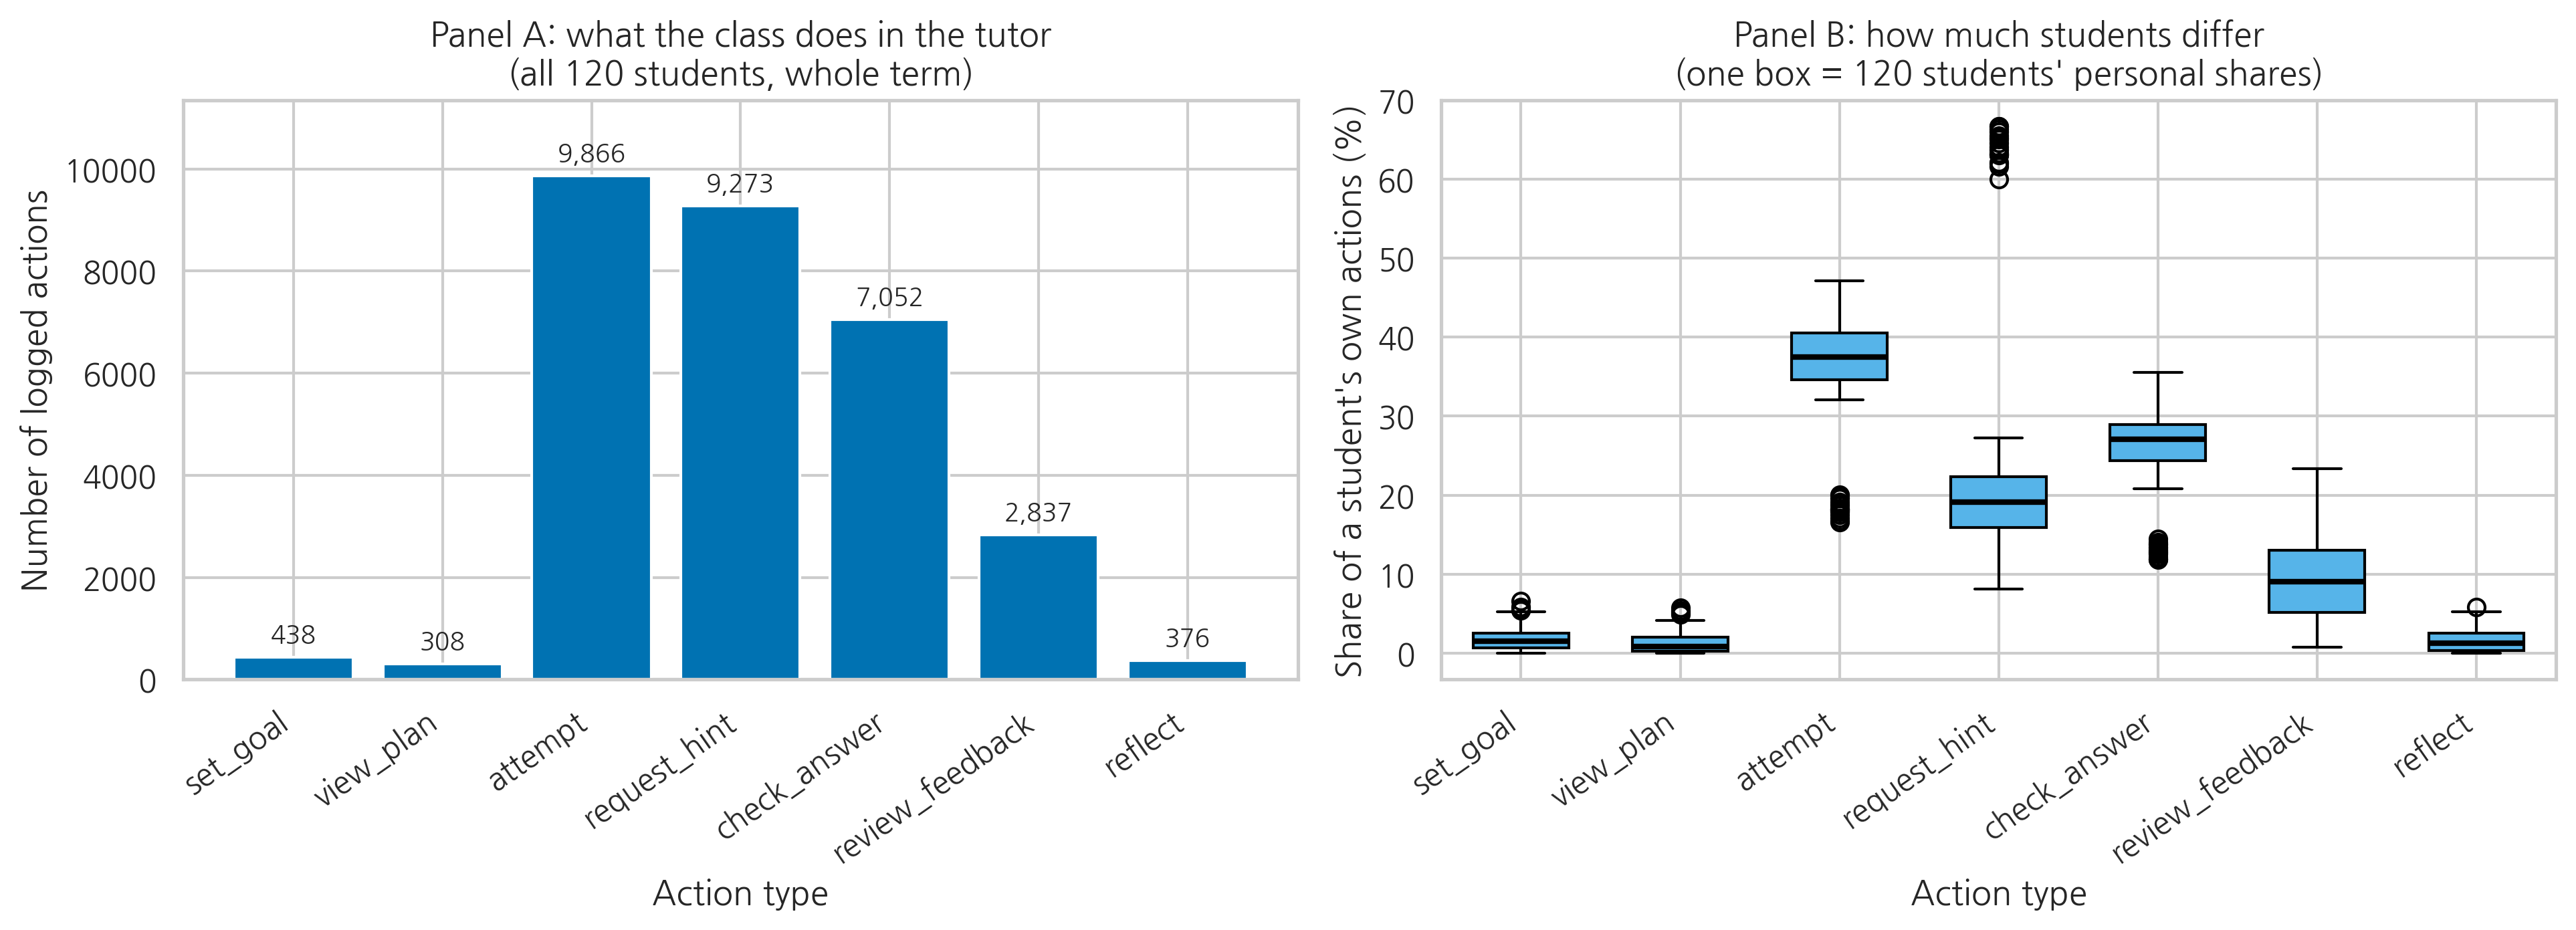

In [5]:
ACTIONS = ["set_goal", "view_plan", "attempt", "request_hint",
           "check_answer", "review_feedback", "reflect"]

# Per student: what share of that student's actions was each action type?
counts_by_student = (traces.groupby(["student_id", "action"]).size()
                     .unstack(fill_value=0)
                     .reindex(columns=ACTIONS, fill_value=0))
profile = counts_by_student.div(counts_by_student.sum(axis=1), axis=0)

print("Action frequency profile, first 5 students (share of that student's actions)")
print(profile.head().round(3).to_string())
print()
print("Spread across students, as percentages of a student's own actions")
spread = (profile.describe().loc[["min", "50%", "max"]] * 100).round(1)
print(spread.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

order = action_counts.reindex(ACTIONS)
axes[0].bar(range(len(ACTIONS)), order.values, color="#0072B2")
axes[0].set_xticks(range(len(ACTIONS)))
axes[0].set_xticklabels(ACTIONS, rotation=35, ha="right")
axes[0].set_ylabel("Number of logged actions")
axes[0].set_xlabel("Action type")
axes[0].set_title("Panel A: what the class does in the tutor\n(all 120 students, whole term)")
for i, v in enumerate(order.values):
    axes[0].text(i, v + 300, f"{v:,}", ha="center", fontsize=9)
axes[0].set_ylim(0, order.max() * 1.15)

box_data = [profile[a].values * 100 for a in ACTIONS]
bp = axes[1].boxplot(box_data, vert=True, patch_artist=True, widths=0.6)
for patch in bp["boxes"]:
    patch.set_facecolor("#56B4E9")
for median in bp["medians"]:
    median.set_color("black")
    median.set_linewidth(2)
axes[1].set_xticks(range(1, len(ACTIONS) + 1))
axes[1].set_xticklabels(ACTIONS, rotation=35, ha="right")
axes[1].set_ylabel("Share of a student's own actions (%)")
axes[1].set_xlabel("Action type")
axes[1].set_title("Panel B: how much students differ\n(one box = 120 students' personal shares)")

plt.tight_layout()
plt.show()

**Interpretation prompt.** Panel A says `attempt` and `request_hint` dominate the log and `reflect` is rare. Panel B says the `request_hint` box is enormous: some students spend under 15 percent of their tutor time asking for hints and some spend over half.

Two questions to answer in a sentence each, before you scroll:

1. A dashboard vendor sells you Panel A as a "self-regulated learning report." What has Panel A actually measured?
2. `reflect` is the rarest action in the log. Name two reasons a student might never fire it, only one of which is about the student.

### ✏️ Your turn 1

Change `FOCUS_STUDENT` to any ID from `S001` to `S120` and rerun the cell to see that student's profile against the class median. The default works as is, so you can also just run it.

In [6]:
# ✏️ TODO: change this to any student ID from S001 to S120.
FOCUS_STUDENT = "S047"

focus = profile.loc[FOCUS_STUDENT] * 100
class_median = profile.median() * 100

comparison = pd.DataFrame({
    f"{FOCUS_STUDENT} (%)": focus.round(1),
    "class median (%)": class_median.round(1),
    "difference": (focus - class_median).round(1),
})
print(f"Action profile for {FOCUS_STUDENT}, compared with the class")
print(comparison.to_string())
print()
print("Total actions logged by this student:", int(counts_by_student.loc[FOCUS_STUDENT].sum()))
print("Tutor sessions attended            :",
      traces.loc[traces['student_id'] == FOCUS_STUDENT, 'session_id'].nunique())

Action profile for S047, compared with the class
                 S047 (%)  class median (%)  difference
action                                                 
set_goal              0.0               1.5        -1.5
view_plan             0.0               0.9        -0.9
attempt              16.6              37.5       -20.9
request_hint         64.1              19.1        45.0
check_answer         11.8              27.1       -15.3
review_feedback       7.3               9.0        -1.7
reflect               0.1               1.3        -1.2

Total actions logged by this student: 752
Tutor sessions attended            : 7


## 📊 2. Complete regulation loops

Profiles count actions. Regulation is about **order**. Setting a goal after you finish is not planning, and looking at feedback you never earned is not reflection. So we need a rule that reads sequences.

Here is the rule we will use. Write it down, because **Week 11 refers back to this exact definition** when we co-design an SRL dashboard.

### Definition: a complete regulation loop

> A tutor session contains a **complete regulation loop** when all three of the following happen **in this order** inside that session:
>
> 1. a `set_goal` action occurs,
> 2. an `attempt` occurs at some point **after** the `set_goal`, and
> 3. a `review_feedback` **or** a `reflect` action occurs at some point **after** that attempt.
>
> The three actions do **not** have to be next to each other. Any number of other actions may sit in between. What the rule cares about is the order: decide what you are doing, do it, then look back at how it went.
>
> A session either contains at least one complete loop or it does not. The measure for a student is their **loop rate**: the share of their tutor sessions that contain one.

Three things this definition is doing, all of them arguable:

- It is a **coarse stand-in** for the recursive phase structure Winne describes, where learners define a task, plan, enact tactics, and then evaluate and adapt. Our `set_goal` stands in for planning, `attempt` for enacting, `review_feedback` or `reflect` for evaluating.
- It treats `review_feedback` and `reflect` as interchangeable closers. That is a choice, and you will get to change it in a moment.
- It ignores **how long** the loop took. A loop that unfolds over twenty minutes and a loop that unfolds over twenty seconds both count. Hold that thought until Section 3.

### Building the pattern matcher

The matcher below is a tiny state machine. It walks through a session's actions once, in order, and remembers how far along the pattern it has gotten. `stage = 0` means still waiting for a goal, `stage = 1` means the goal is set and we are waiting for an attempt, `stage = 2` means we are waiting for the loop to close.

You do not have to be able to write this. You do have to be able to say what it would do to a session you invented, which is what the demo prints.

In [7]:
LOOP_CLOSERS = ("review_feedback", "reflect")

def has_complete_loop(action_sequence, closers=LOOP_CLOSERS):
    """Return True if this ordered list of actions contains set_goal -> attempt -> closer.

    The three actions need not be adjacent; only their relative order matters.
    """
    stage = 0                        # 0 = need a goal, 1 = need an attempt, 2 = need a closer
    for action in action_sequence:
        if stage == 0 and action == "set_goal":
            stage = 1
        elif stage == 1 and action == "attempt":
            stage = 2
        elif stage == 2 and action in closers:
            return True
    return False

# Demo on hand-made sessions, so the rule is visible before we trust it on 844 real ones.
demos = [
    ["set_goal", "attempt", "check_answer", "review_feedback"],
    ["set_goal", "view_plan", "request_hint", "attempt", "check_answer", "reflect"],
    ["attempt", "check_answer", "review_feedback", "set_goal"],
    ["set_goal", "request_hint", "request_hint", "request_hint", "attempt"],
    ["attempt", "attempt", "attempt", "check_answer"],
]
print("Does this session contain a complete regulation loop?")
print("-" * 78)
for seq in demos:
    verdict = "YES" if has_complete_loop(seq) else "no "
    print(f"{verdict}  {' -> '.join(seq)}")

Does this session contain a complete regulation loop?
------------------------------------------------------------------------------
YES  set_goal -> attempt -> check_answer -> review_feedback
YES  set_goal -> view_plan -> request_hint -> attempt -> check_answer -> reflect
no   attempt -> check_answer -> review_feedback -> set_goal
no   set_goal -> request_hint -> request_hint -> request_hint -> attempt
no   attempt -> attempt -> attempt -> check_answer


**Read the demo, do not skip it.** Row 3 fails because the goal arrives last: the actions are all present, the order is wrong. Row 4 fails because the student never closed the loop, which is the most common way a real session falls short. If the rule surprises you anywhere, that is the moment to argue with it rather than with the results it produces later.

### Applying the matcher to all 844 real sessions

Now we run the same function over every student by session pair. The result is one row per session with a True or False, which we then average per student to get their loop rate.

In [8]:
# One row per session, holding the ordered list of actions in that session.
session_actions = (traces.groupby(["student_id", "session_id"])["action"]
                   .apply(list)
                   .reset_index()
                   .rename(columns={"action": "action_sequence"}))

session_actions["complete_loop"] = session_actions["action_sequence"].apply(has_complete_loop)
session_actions["n_actions"] = session_actions["action_sequence"].apply(len)

loop_rate = session_actions.groupby("student_id")["complete_loop"].mean()
loop_rate.name = "loop_rate"

n_sessions = len(session_actions)
print(f"Tutor sessions analyzed            : {n_sessions}")
print(f"Sessions with a complete loop      : {session_actions['complete_loop'].sum()}"
      f"  ({session_actions['complete_loop'].mean():.1%})")
print()

# Where do the incomplete sessions break down? This is the diagnostic that matters.
has_goal = session_actions["action_sequence"].apply(lambda s: "set_goal" in s)
has_closer = session_actions["action_sequence"].apply(
    lambda s: any(a in LOOP_CLOSERS for a in s))
print("Why sessions fail the rule")
print(f"  no set_goal anywhere in the session : {(~has_goal).sum():>4}  ({(~has_goal).mean():.1%})")
print(f"  no closing action anywhere          : {(~has_closer).sum():>4}  ({(~has_closer).mean():.1%})")
print(f"  has both, but in the wrong order    : "
      f"{(has_goal & has_closer & ~session_actions['complete_loop']).sum():>4}")
print()
print("Loop rate per student, summary")
print(loop_rate.describe().round(3).to_string())

Tutor sessions analyzed            : 844
Sessions with a complete loop      : 410  (48.6%)

Why sessions fail the rule
  no set_goal anywhere in the session :  406  (48.1%)
  no closing action anywhere          :   89  (10.5%)
  has both, but in the wrong order    :    0

Loop rate per student, summary
count    120.000
mean       0.488
std        0.313
min        0.000
25%        0.250
50%        0.429
75%        0.723
max        1.000


### Does any of this go with learning?

A loop rate is just a behavior count until you connect it to something a teacher would care about. Our outcome is **quiz growth**: for each student we fit a straight line through their eight quiz scores and keep the slope. A slope of +1.0 means that student gained about one point per quiz across the term. A slope of -1.0 means they lost about one point per quiz.

Growth, not average score, is the right outcome here. Average score mostly tells you who arrived well prepared. Slope asks whether the student moved.

In [9]:
quizzes = gradebook[gradebook["assessment"].str.startswith("quiz")].copy()
quizzes["quiz_number"] = quizzes["assessment"].str.replace("quiz_", "", regex=False).astype(int)

# Fit one straight line per student: score against quiz number. The slope is the growth rate.
slopes = {}
for student_id, one_student in quizzes.groupby("student_id"):
    one_student = one_student.sort_values("quiz_number")
    slope, intercept = np.polyfit(one_student["quiz_number"], one_student["score"], 1)
    slopes[student_id] = slope
quiz_slope = pd.Series(slopes, name="quiz_slope")

srl = pd.DataFrame({"loop_rate": loop_rate, "quiz_slope": quiz_slope}).dropna()
r_loop = srl["loop_rate"].corr(srl["quiz_slope"])

print("Quiz growth slope, points gained per quiz")
print(quiz_slope.describe().round(2).to_string())
print()
print(f"Correlation between loop rate and quiz growth: r = {r_loop:.2f}  (n = {len(srl)})")
print()

srl["loop_group"] = pd.qcut(srl["loop_rate"], 3, labels=["lowest third", "middle third", "highest third"])
table = srl.groupby("loop_group", observed=True)["quiz_slope"].agg(
    students="count", mean_growth="mean", sd="std").round(2)
print("Quiz growth by loop rate tercile")
print(table.to_string())

Quiz growth slope, points gained per quiz
count    120.00
mean       0.03
std        1.27
min       -3.38
25%       -1.03
50%        0.09
75%        0.85
max        3.08

Correlation between loop rate and quiz growth: r = 0.58  (n = 120)

Quiz growth by loop rate tercile
               students  mean_growth    sd
loop_group                                
lowest third         43        -0.82  1.17
middle third         39         0.14  0.96
highest third        38         0.88  1.04


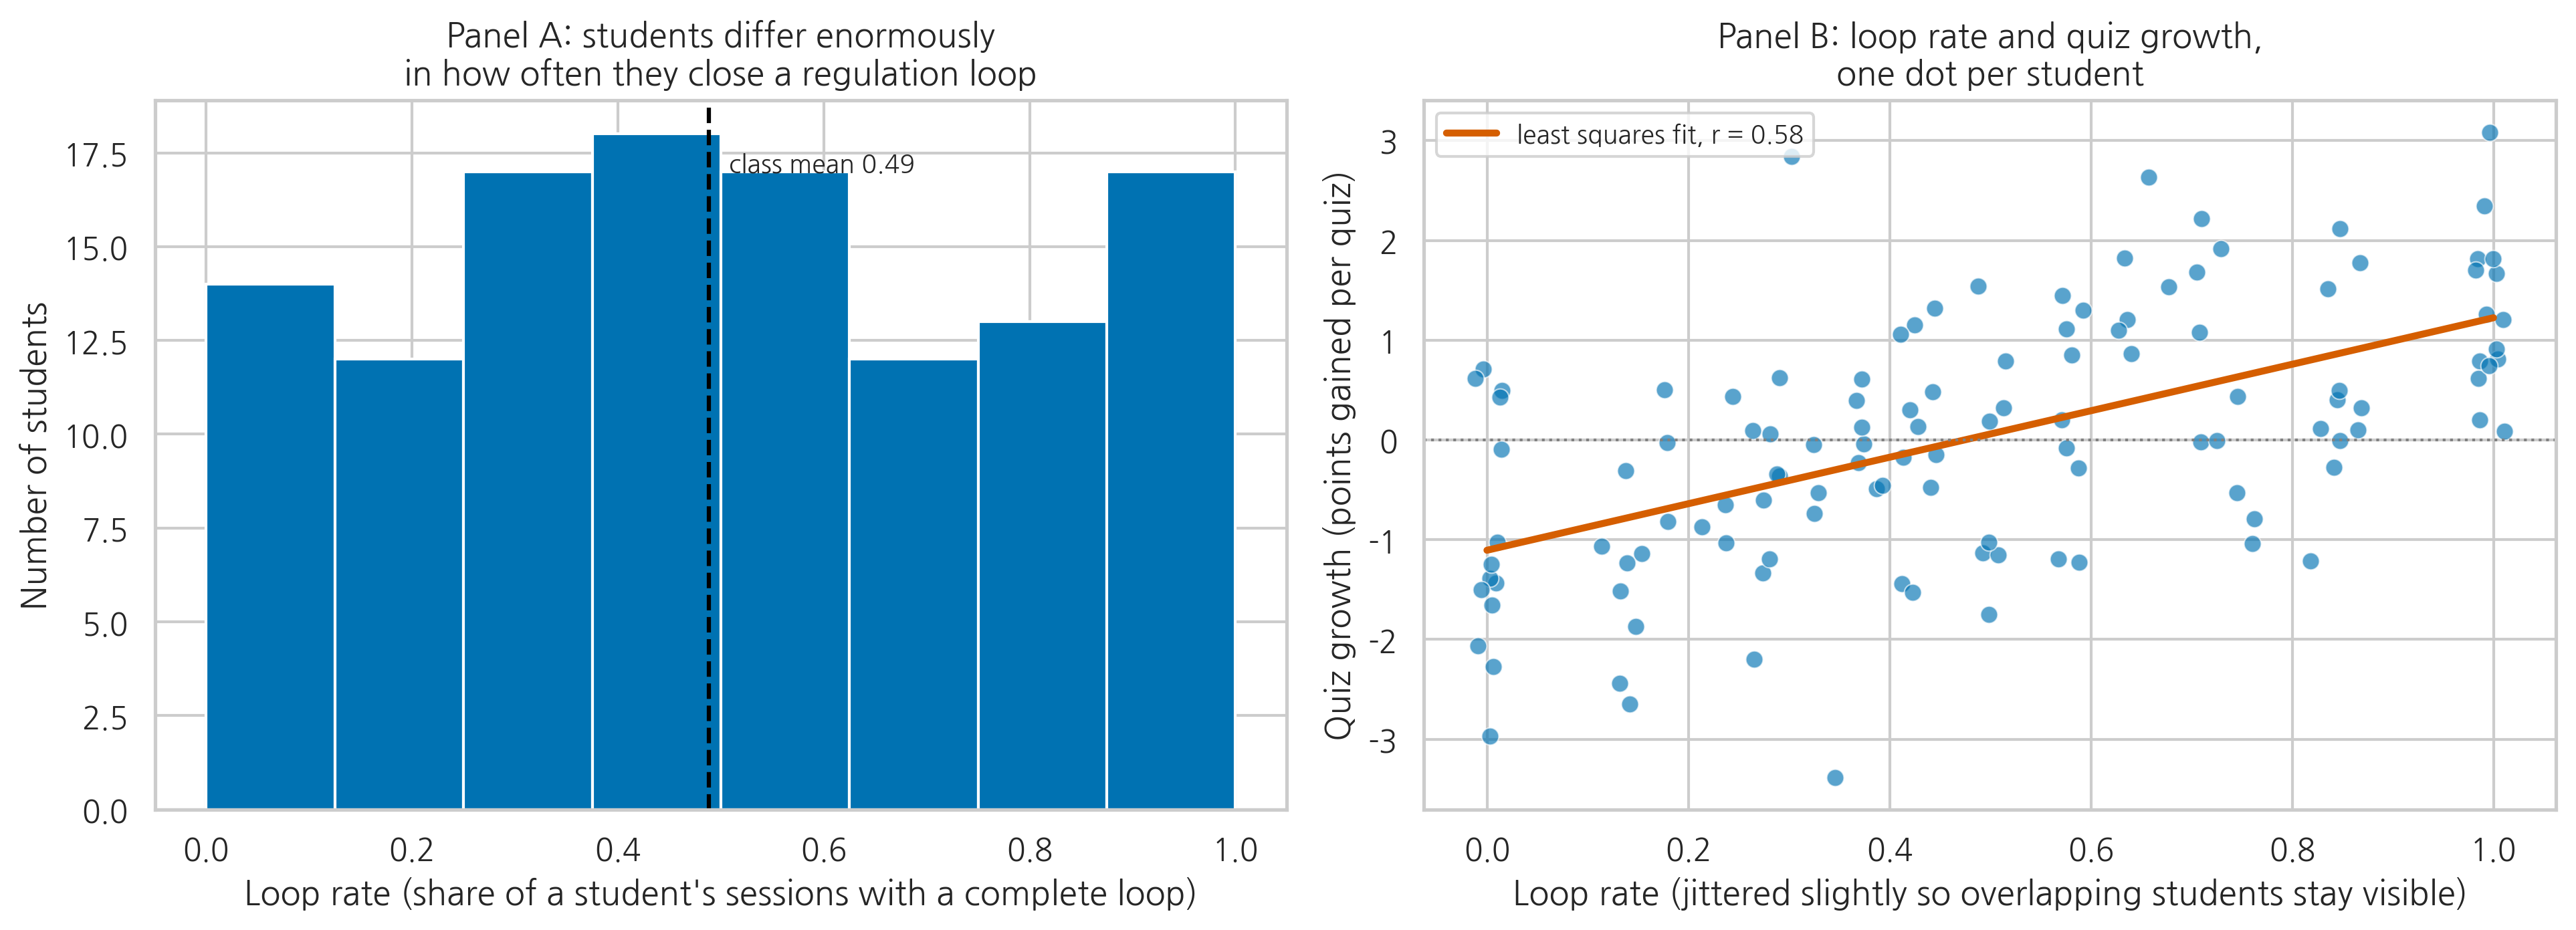

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].hist(srl["loop_rate"], bins=np.arange(0, 1.1, 0.125),
             color="#0072B2", edgecolor="white")
axes[0].set_xlabel("Loop rate (share of a student's sessions with a complete loop)")
axes[0].set_ylabel("Number of students")
axes[0].set_title("Panel A: students differ enormously\nin how often they close a regulation loop")
axes[0].axvline(srl["loop_rate"].mean(), color="black", linestyle="--", linewidth=1.5)
axes[0].text(srl["loop_rate"].mean() + 0.02, axes[0].get_ylim()[1] * 0.9,
             f"class mean {srl['loop_rate'].mean():.2f}", fontsize=9)

# Loop rates land on a few discrete values (sessions are counted in whole numbers),
# so we nudge the points sideways a little to keep overlapping students visible.
rng = np.random.default_rng(8100)
jitter = rng.uniform(-0.018, 0.018, size=len(srl))
axes[1].scatter(srl["loop_rate"] + jitter, srl["quiz_slope"],
                s=38, alpha=0.65, color="#0072B2", edgecolor="white", linewidth=0.5)
fit = np.polyfit(srl["loop_rate"], srl["quiz_slope"], 1)
xs = np.linspace(0, 1, 50)
axes[1].plot(xs, np.polyval(fit, xs), color="#D55E00", linewidth=2.5,
             label=f"least squares fit, r = {r_loop:.2f}")
axes[1].axhline(0, color="grey", linewidth=1, linestyle=":")
axes[1].set_xlabel("Loop rate (jittered slightly so overlapping students stay visible)")
axes[1].set_ylabel("Quiz growth (points gained per quiz)")
axes[1].set_title("Panel B: loop rate and quiz growth,\none dot per student")
axes[1].legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

**Interpretation prompt.** Panel B is a real relationship and a noisy one: students at a loop rate of 0.75 span growth slopes from clearly negative to clearly positive. Answer these three:

1. Write the finding as a sentence you would be willing to defend in a dissertation proposal. Now write the version you would refuse to defend, the one with the word "because" in it.
2. A student with a loop rate of 0 might be a student who never regulates, or a student whose regulation the tutor has no button for. How would you tell those two apart with data this tutor could realistically collect?
3. The dots at loop rate 1.0 are not all thriving. What is that dispersion telling you about using loop rate as a dashboard indicator for an individual student?

### ✏️ Your turn 2

The definition treats `review_feedback` and `reflect` as equally good ways to close a loop. That was a design decision, not a fact. Tighten it: make `reflect` the only acceptable closer, and see what happens to the loop rate and to the correlation with growth.

The default below is the strict version, so the cell runs as is. Change it back to `("review_feedback", "reflect")` to compare, or invent your own.

In [11]:
# ✏️ TODO: edit this tuple and rerun. Try ("reflect",) alone, then ("review_feedback", "reflect"),
# then something you can defend, like ("reflect", "view_plan").
MY_CLOSERS = ("reflect",)

my_loop = session_actions["action_sequence"].apply(
    lambda seq: has_complete_loop(seq, closers=MY_CLOSERS))
my_rate = my_loop.groupby(session_actions["student_id"]).mean()
my_r = my_rate.corr(quiz_slope)

print(f"Closers used                       : {MY_CLOSERS}")
print(f"Sessions counted as complete loops : {my_loop.sum()} of {len(my_loop)} ({my_loop.mean():.1%})")
print(f"Correlation with quiz growth       : r = {my_r:.2f}")
print()
print(f"For comparison, the notebook default {LOOP_CLOSERS}")
print(f"  complete loops: {session_actions['complete_loop'].mean():.1%},  r = {r_loop:.2f}")
print()
print("If your r moved, ask why. A measurement decision just changed a finding.")

Closers used                       : ('reflect',)
Sessions counted as complete loops : 258 of 844 (30.6%)
Correlation with quiz growth       : r = 0.52

For comparison, the notebook default ('review_feedback', 'reflect')
  complete loops: 48.6%,  r = 0.58

If your r moved, ask why. A measurement decision just changed a finding.


## 📊 3. Hint spam, and why counting will not find it

Here is a claim worth being suspicious of: "students who ask for many hints are gaming the system."

Asking for a lot of hints can mean a student is stuck and seeking help, which is a regulation strategy, not a failure of one. It can also mean a student is clicking the hint button until the tutor gives away the answer. **The counts look identical. Only the clock can tell them apart.**

So we compute the gap in seconds between each action and the one before it, within the same session, and look at what happens right before a hint request.

Seconds between the previous action and a hint request
count    9043.0
mean       18.0
std        20.7
min         1.0
10%         3.0
25%         4.0
50%         8.0
75%        22.0
90%        52.0
max        95.0

Hint requests arriving within 5 seconds of the previous action : 29.7%
Hint requests arriving within 10 seconds                       : 51.9%


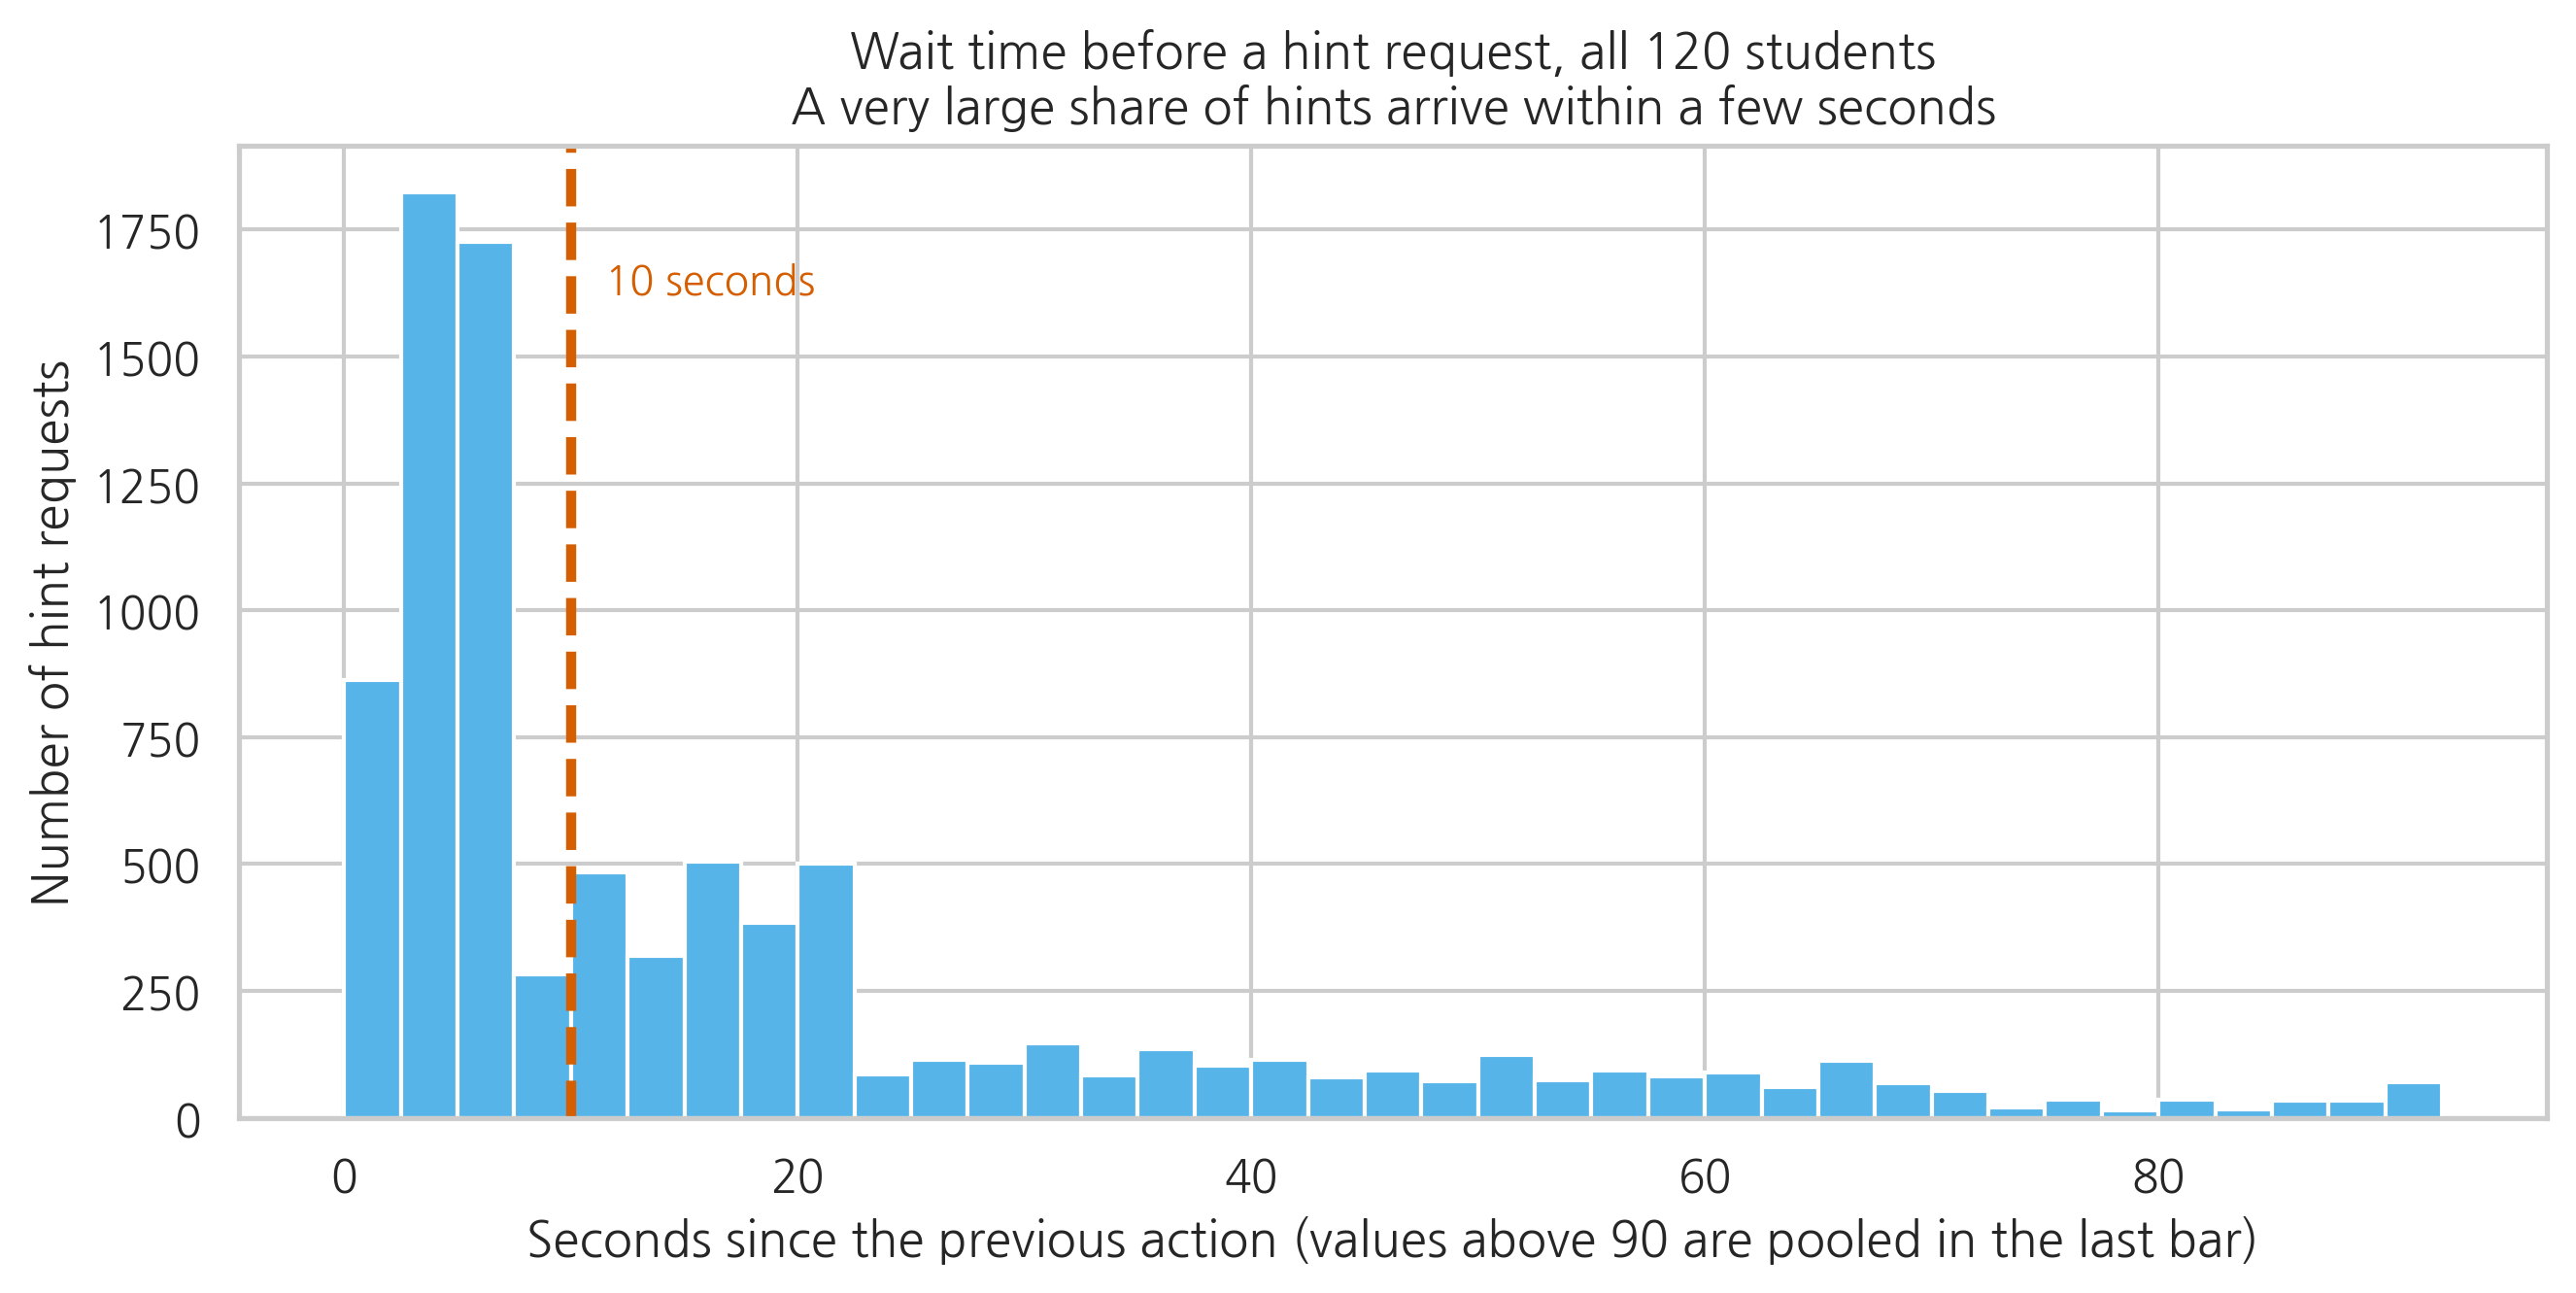

In [12]:
# Seconds since the previous action, computed within a session so we never
# measure across a two week break between sessions.
traces["gap_s"] = (traces.groupby(["student_id", "session_id"])["timestamp"]
                   .diff().dt.total_seconds())
traces["previous_action"] = (traces.groupby(["student_id", "session_id"])["action"]
                             .shift(1))

hint_gaps = traces.loc[traces["action"] == "request_hint", "gap_s"].dropna()

print("Seconds between the previous action and a hint request")
print(hint_gaps.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(1).to_string())
print()
print(f"Hint requests arriving within 5 seconds of the previous action : {(hint_gaps < 5).mean():.1%}")
print(f"Hint requests arriving within 10 seconds                       : {(hint_gaps < 10).mean():.1%}")

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.hist(hint_gaps.clip(upper=90), bins=np.arange(0, 95, 2.5),
        color="#56B4E9", edgecolor="white")
ax.axvline(10, color="#D55E00", linewidth=2.5, linestyle="--")
ax.text(11.5, ax.get_ylim()[1] * 0.85, "10 seconds", color="#D55E00", fontsize=10)
ax.set_xlabel("Seconds since the previous action (values above 90 are pooled in the last bar)")
ax.set_ylabel("Number of hint requests")
ax.set_title("Wait time before a hint request, all 120 students\nA very large share of hints arrive within a few seconds")
plt.tight_layout()
plt.show()

**Interpretation prompt.** This distribution has a tall spike near zero and a long tail. Before reading on: is the spike a problem, or is it just what fast, fluent practice looks like? What additional column would settle it for you?

### A rule for hint spam

A single fast hint is nothing. Someone reads a problem, recognizes it as unfamiliar, and asks. What is not nothing is a **run** of them.

> **Hint burst**: three or more consecutive `request_hint` actions in the same session, where each one arrives within 10 seconds of the action before it.
>
> A student is flagged as **hint spamming** if they produce at least 3 hint bursts across the term.

Both numbers in that rule (10 seconds, 3 bursts) are ours, not the data's. You will get to move them in a minute, and you should.

In [13]:
RAPID_GAP_SECONDS = 10   # a hint arriving faster than this counts as "rapid"
MIN_BURST_LENGTH = 3     # this many rapid hints in a row makes a burst
MIN_BURSTS_TO_FLAG = 3   # this many bursts across the term flags a student

# A "rapid repeat" is a hint request that follows another hint request very quickly.
traces["rapid_repeat_hint"] = (
    (traces["action"] == "request_hint") &
    (traces["previous_action"] == "request_hint") &
    (traces["gap_s"] < RAPID_GAP_SECONDS)
)

def count_bursts(flags, min_length=MIN_BURST_LENGTH):
    """Count runs of rapid repeats. A burst of k hints has k-1 rapid repeats in a row."""
    needed = min_length - 1
    bursts, run = 0, 0
    for is_rapid in flags:
        if is_rapid:
            run += 1
        else:
            if run >= needed:
                bursts += 1
            run = 0
    if run >= needed:
        bursts += 1
    return bursts

hint_bursts = traces.groupby("student_id")["rapid_repeat_hint"].apply(count_bursts)
hint_bursts.name = "hint_bursts"

sessions_attended = traces.groupby("student_id")["session_id"].nunique()
hints_total = (traces[traces["action"] == "request_hint"].groupby("student_id").size()
               .reindex(hint_bursts.index, fill_value=0))
hints_per_session = (hints_total / sessions_attended).rename("hints_per_session")
median_wait = (traces[traces["action"] == "request_hint"]
               .groupby("student_id")["gap_s"].median().rename("median_wait_s"))

hint_spam = (hint_bursts >= MIN_BURSTS_TO_FLAG).rename("hint_spam")

print(f"Students flagged as hint spamming: {hint_spam.sum()} of {len(hint_spam)}")
print()
summary = pd.DataFrame({
    "students": [(~hint_spam).sum(), hint_spam.sum()],
    "mean hints per session": [hints_per_session[~hint_spam].mean(), hints_per_session[hint_spam].mean()],
    "mean median wait (s)": [median_wait[~hint_spam].mean(), median_wait[hint_spam].mean()],
    "mean bursts": [hint_bursts[~hint_spam].mean(), hint_bursts[hint_spam].mean()],
}, index=["not flagged", "flagged"]).round(1)
print(summary.to_string())

Students flagged as hint spamming: 18 of 120

             students  mean hints per session  mean median wait (s)  mean bursts
not flagged       102                     5.9                  21.4          0.0
flagged            18                    40.0                   4.3         54.0


### The two students the counts cannot separate

The table above is an average. Averages are where evidence goes to hide. So look at two actual students:

- **S017** is the heaviest hint user in the whole class who was *not* flagged.
- **S072** is the *lightest* hint user among the flagged students.

If hint counts were enough, these two would be neighbors. Watch the clock instead.

In [14]:
def hint_portrait(student_id):
    print(f"{student_id}: {hints_per_session[student_id]:.1f} hints per session, "
          f"median wait before a hint {median_wait[student_id]:.0f} s, "
          f"{hint_bursts[student_id]} bursts, "
          f"flagged = {bool(hint_spam[student_id])}")

hint_portrait("S017")
hint_portrait("S072")
print()

def show_hint_window(student_id, session_id, n_rows=14):
    one = traces[(traces["student_id"] == student_id) &
                 (traces["session_id"] == session_id)]
    view = one[["action", "gap_s"]].head(n_rows).rename(
        columns={"gap_s": "seconds_since_previous"})
    print(f"--- {student_id}, {session_id} ---")
    print(view.to_string(index=False))
    print()

show_hint_window("S017", "tutor_1")
show_hint_window("S072", "tutor_4")

S017: 14.2 hints per session, median wait before a hint 21 s, 0 bursts, flagged = False
S072: 21.0 hints per session, median wait before a hint 4 s, 33 bursts, flagged = True

--- S017, tutor_1 ---
         action  seconds_since_previous
   request_hint                     NaN
        attempt                    22.0
   check_answer                    82.0
review_feedback                    12.0
   request_hint                    60.0
        attempt                    18.0
   request_hint                    56.0
        attempt                    32.0
   check_answer                    65.0
   request_hint                    22.0
        attempt                    37.0
   check_answer                    60.0
review_feedback                    15.0
   request_hint                    13.0

--- S072, tutor_4 ---
      action  seconds_since_previous
    set_goal                     NaN
   view_plan                    17.0
request_hint                    35.0
request_hint                   

**Interpretation prompt.** S017 asks for a lot of hints and waits 20 seconds or more before most of them, threaded between attempts and feedback. S072 fires six hints in nineteen seconds and then attempts. Nobody reads a hint in three seconds.

Write one sentence describing what each student is probably doing. Then write the sentence a dashboard would have shown a teacher if it reported only "hints requested this week."

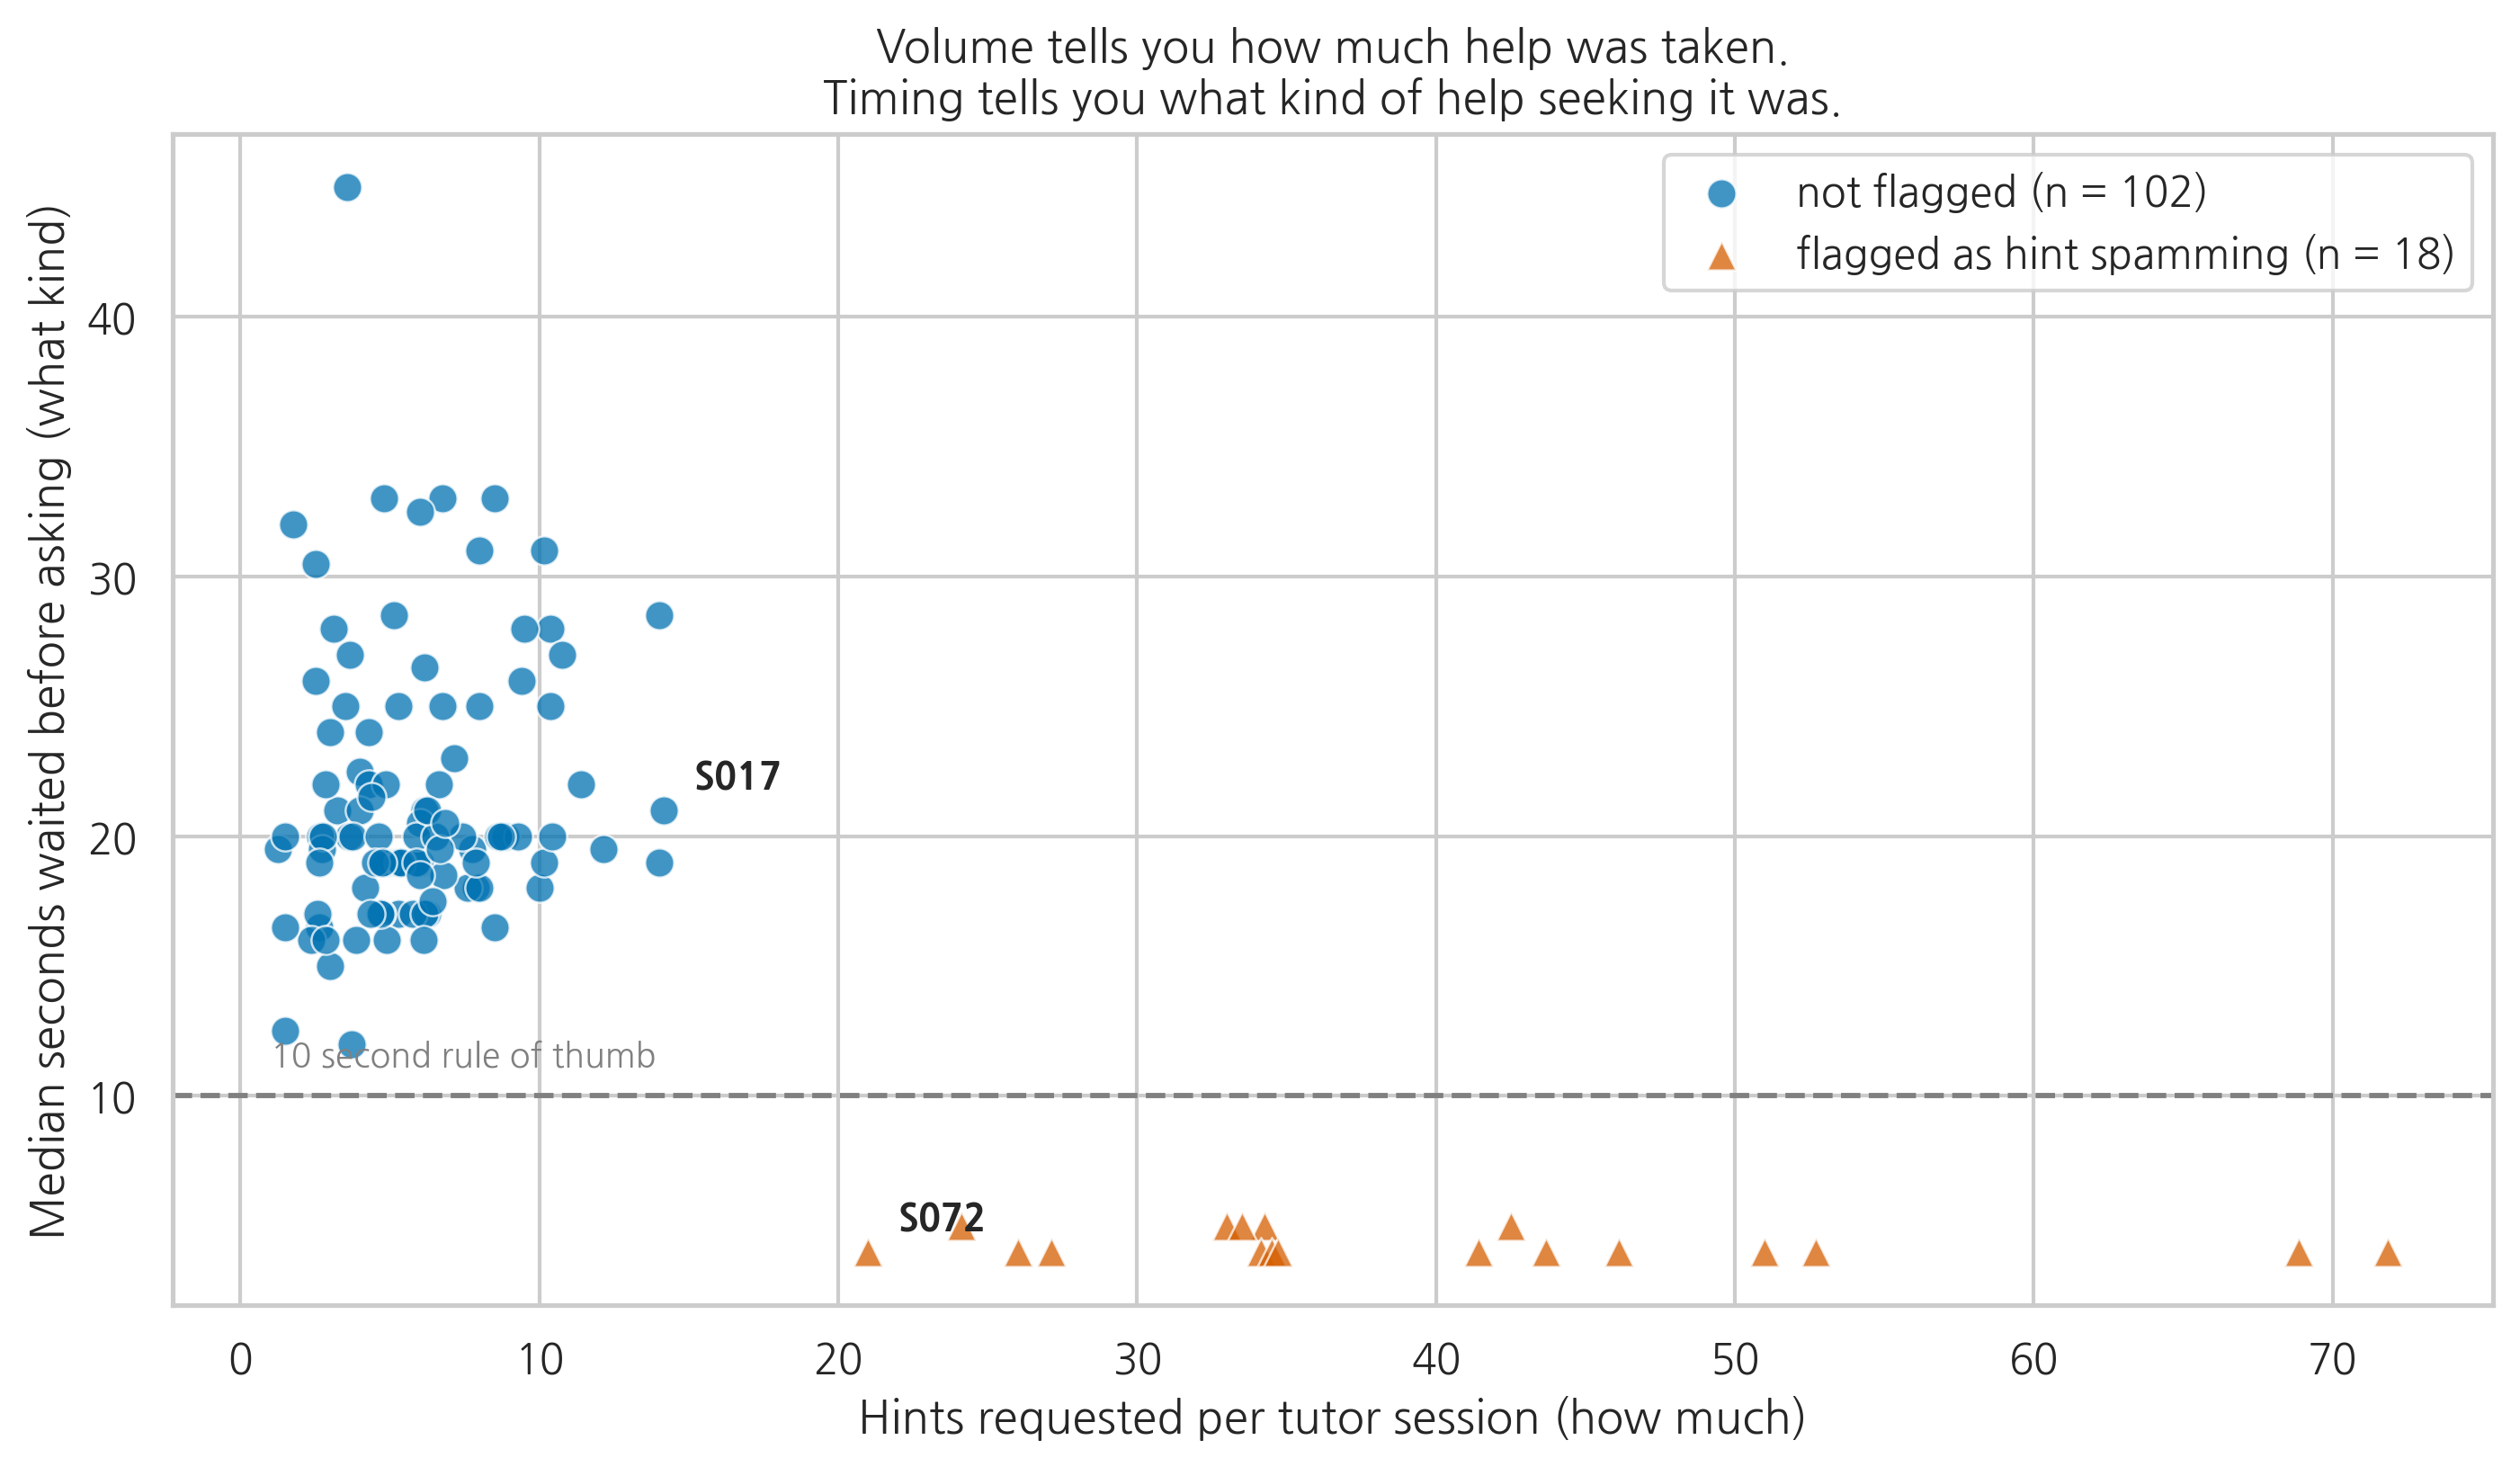

In [15]:
hint_profile = pd.concat([hints_per_session, median_wait, hint_bursts, hint_spam], axis=1)

fig, ax = plt.subplots(figsize=(9.5, 5.6))
for flagged, colour, marker, label in [
    (False, "#0072B2", "o", f"not flagged (n = {(~hint_spam).sum()})"),
    (True, "#D55E00", "^", f"flagged as hint spamming (n = {hint_spam.sum()})"),
]:
    part = hint_profile[hint_profile["hint_spam"] == flagged]
    ax.scatter(part["hints_per_session"], part["median_wait_s"],
               s=60, alpha=0.75, color=colour, marker=marker,
               edgecolor="white", linewidth=0.6, label=label)

ax.axhline(RAPID_GAP_SECONDS, color="grey", linestyle="--", linewidth=1.4)
ax.text(1, RAPID_GAP_SECONDS + 1.2, f"{RAPID_GAP_SECONDS} second rule of thumb",
        fontsize=9, color="grey")
for sid in ["S017", "S072"]:
    ax.annotate(sid, (hint_profile.loc[sid, "hints_per_session"],
                      hint_profile.loc[sid, "median_wait_s"]),
                textcoords="offset points", xytext=(8, 6), fontsize=10, weight="bold")
ax.set_xlabel("Hints requested per tutor session (how much)")
ax.set_ylabel("Median seconds waited before asking (what kind)")
ax.set_title("Volume tells you how much help was taken.\nTiming tells you what kind of help seeking it was.")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

**Interpretation prompt.** Two groups separate cleanly on the vertical axis: every flagged student waits a median of 5 seconds or less, every unflagged student waits at least 12.

Be careful here, because in *this* dataset the two groups also separate on the horizontal axis, so a lazy analyst who only counted hints would have gotten roughly the right list of students this time. That is luck, not method.

1. Describe a real tutoring system where the horizontal separation would vanish while the vertical separation stayed. What kind of student would a count-only flag then miss?
2. Now the harder direction. Who does a timing-based flag wrongly catch? Think about a student on a shared laptop, a student with a screen reader, a student who already knows the material and is skimming. What would you need to know before this flag is allowed to reach a teacher?

### ✏️ Your turn 3

Move the thresholds. This is the most important cell in the notebook, because it shows you how much of a "finding" is a decision you made.

The defaults below are the notebook's own settings, so the cell runs untouched. Try 5 seconds, then 30. Try requiring 2 hints in a row, then 5.

In [16]:
# ✏️ TODO: change one number at a time and rerun.
MY_GAP_SECONDS = 10     # try 5, then 30
MY_BURST_LENGTH = 3     # try 2, then 5
MY_MIN_BURSTS = 3       # try 1, then 10

my_rapid = ((traces["action"] == "request_hint") &
            (traces["previous_action"] == "request_hint") &
            (traces["gap_s"] < MY_GAP_SECONDS))
my_bursts = my_rapid.groupby(traces["student_id"]).apply(
    lambda flags: count_bursts(flags, min_length=MY_BURST_LENGTH))
my_flag = my_bursts >= MY_MIN_BURSTS

print(f"Rule: {MY_BURST_LENGTH}+ hints in a row, each within {MY_GAP_SECONDS} s, "
      f"at least {MY_MIN_BURSTS} times across the term")
print(f"Students flagged: {my_flag.sum()} of {len(my_flag)}")
print(f"Agreement with the notebook default: "
      f"{(my_flag == hint_spam).mean():.1%} of students classified the same way")
changed = hint_spam.index[my_flag != hint_spam].tolist()
print(f"Students whose label changed: {changed if changed else 'none'}")
print()
print("A flag that swings when you move a number by 5 seconds is a hypothesis, not a finding.")

Rule: 3+ hints in a row, each within 10 s, at least 3 times across the term


Students flagged: 18 of 120
Agreement with the notebook default: 100.0% of students classified the same way
Students whose label changed: none

A flag that swings when you move a number by 5 seconds is a hypothesis, not a finding.


## 📊 4. Putting the two behaviors next to learning

We now have two trace-derived measures: a loop rate and a hint spam flag. Sort every student into one of three profiles and compare quiz growth.

- **Frequent loopers**: not flagged, and complete a loop in at least half of their sessions.
- **Everyone else**: not flagged, lower loop rate.
- **Hint spammers**: flagged by the burst rule.

Look at the chart before you read the prose under it.

In [17]:
srl["hint_spam"] = hint_spam.reindex(srl.index).fillna(False)
srl["hint_bursts"] = hint_bursts.reindex(srl.index).fillna(0)

def label_profile(row):
    if row["hint_spam"]:
        return "hint spammers"
    if row["loop_rate"] >= 0.5:
        return "frequent loopers"
    return "everyone else"

srl["profile"] = srl.apply(label_profile, axis=1)
GROUP_ORDER = ["hint spammers", "everyone else", "frequent loopers"]

group_table = (srl.groupby("profile")[["quiz_slope", "loop_rate"]]
               .agg(["count", "mean", "std"])
               .loc[GROUP_ORDER].round(2))
group_table.columns = ["n", "mean growth", "sd growth", "n2", "mean loop rate", "sd loop rate"]
print("Quiz growth and loop rate by trace profile")
print(group_table[["n", "mean growth", "sd growth", "mean loop rate"]].to_string())
print()

def cohens_d(a, b):
    pooled = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    return (a.mean() - b.mean()) / pooled

spammers = srl.loc[srl["hint_spam"], "quiz_slope"]
others = srl.loc[~srl["hint_spam"], "quiz_slope"]
loopers = srl.loc[srl["profile"] == "frequent loopers", "quiz_slope"]
not_loopers = srl.loc[srl["profile"] != "frequent loopers", "quiz_slope"]
print(f"Hint spammers versus everyone else : d = {cohens_d(spammers, others):+.2f}")
print(f"Frequent loopers versus the rest   : d = {cohens_d(loopers, not_loopers):+.2f}")

Quiz growth and loop rate by trace profile
                   n  mean growth  sd growth  mean loop rate
profile                                                     
hint spammers     18        -0.55       1.10            0.20
everyone else     44        -0.56       1.15            0.25
frequent loopers  58         0.66       1.10            0.76

Hint spammers versus everyone else : d = -0.57
Frequent loopers versus the rest   : d = +1.09


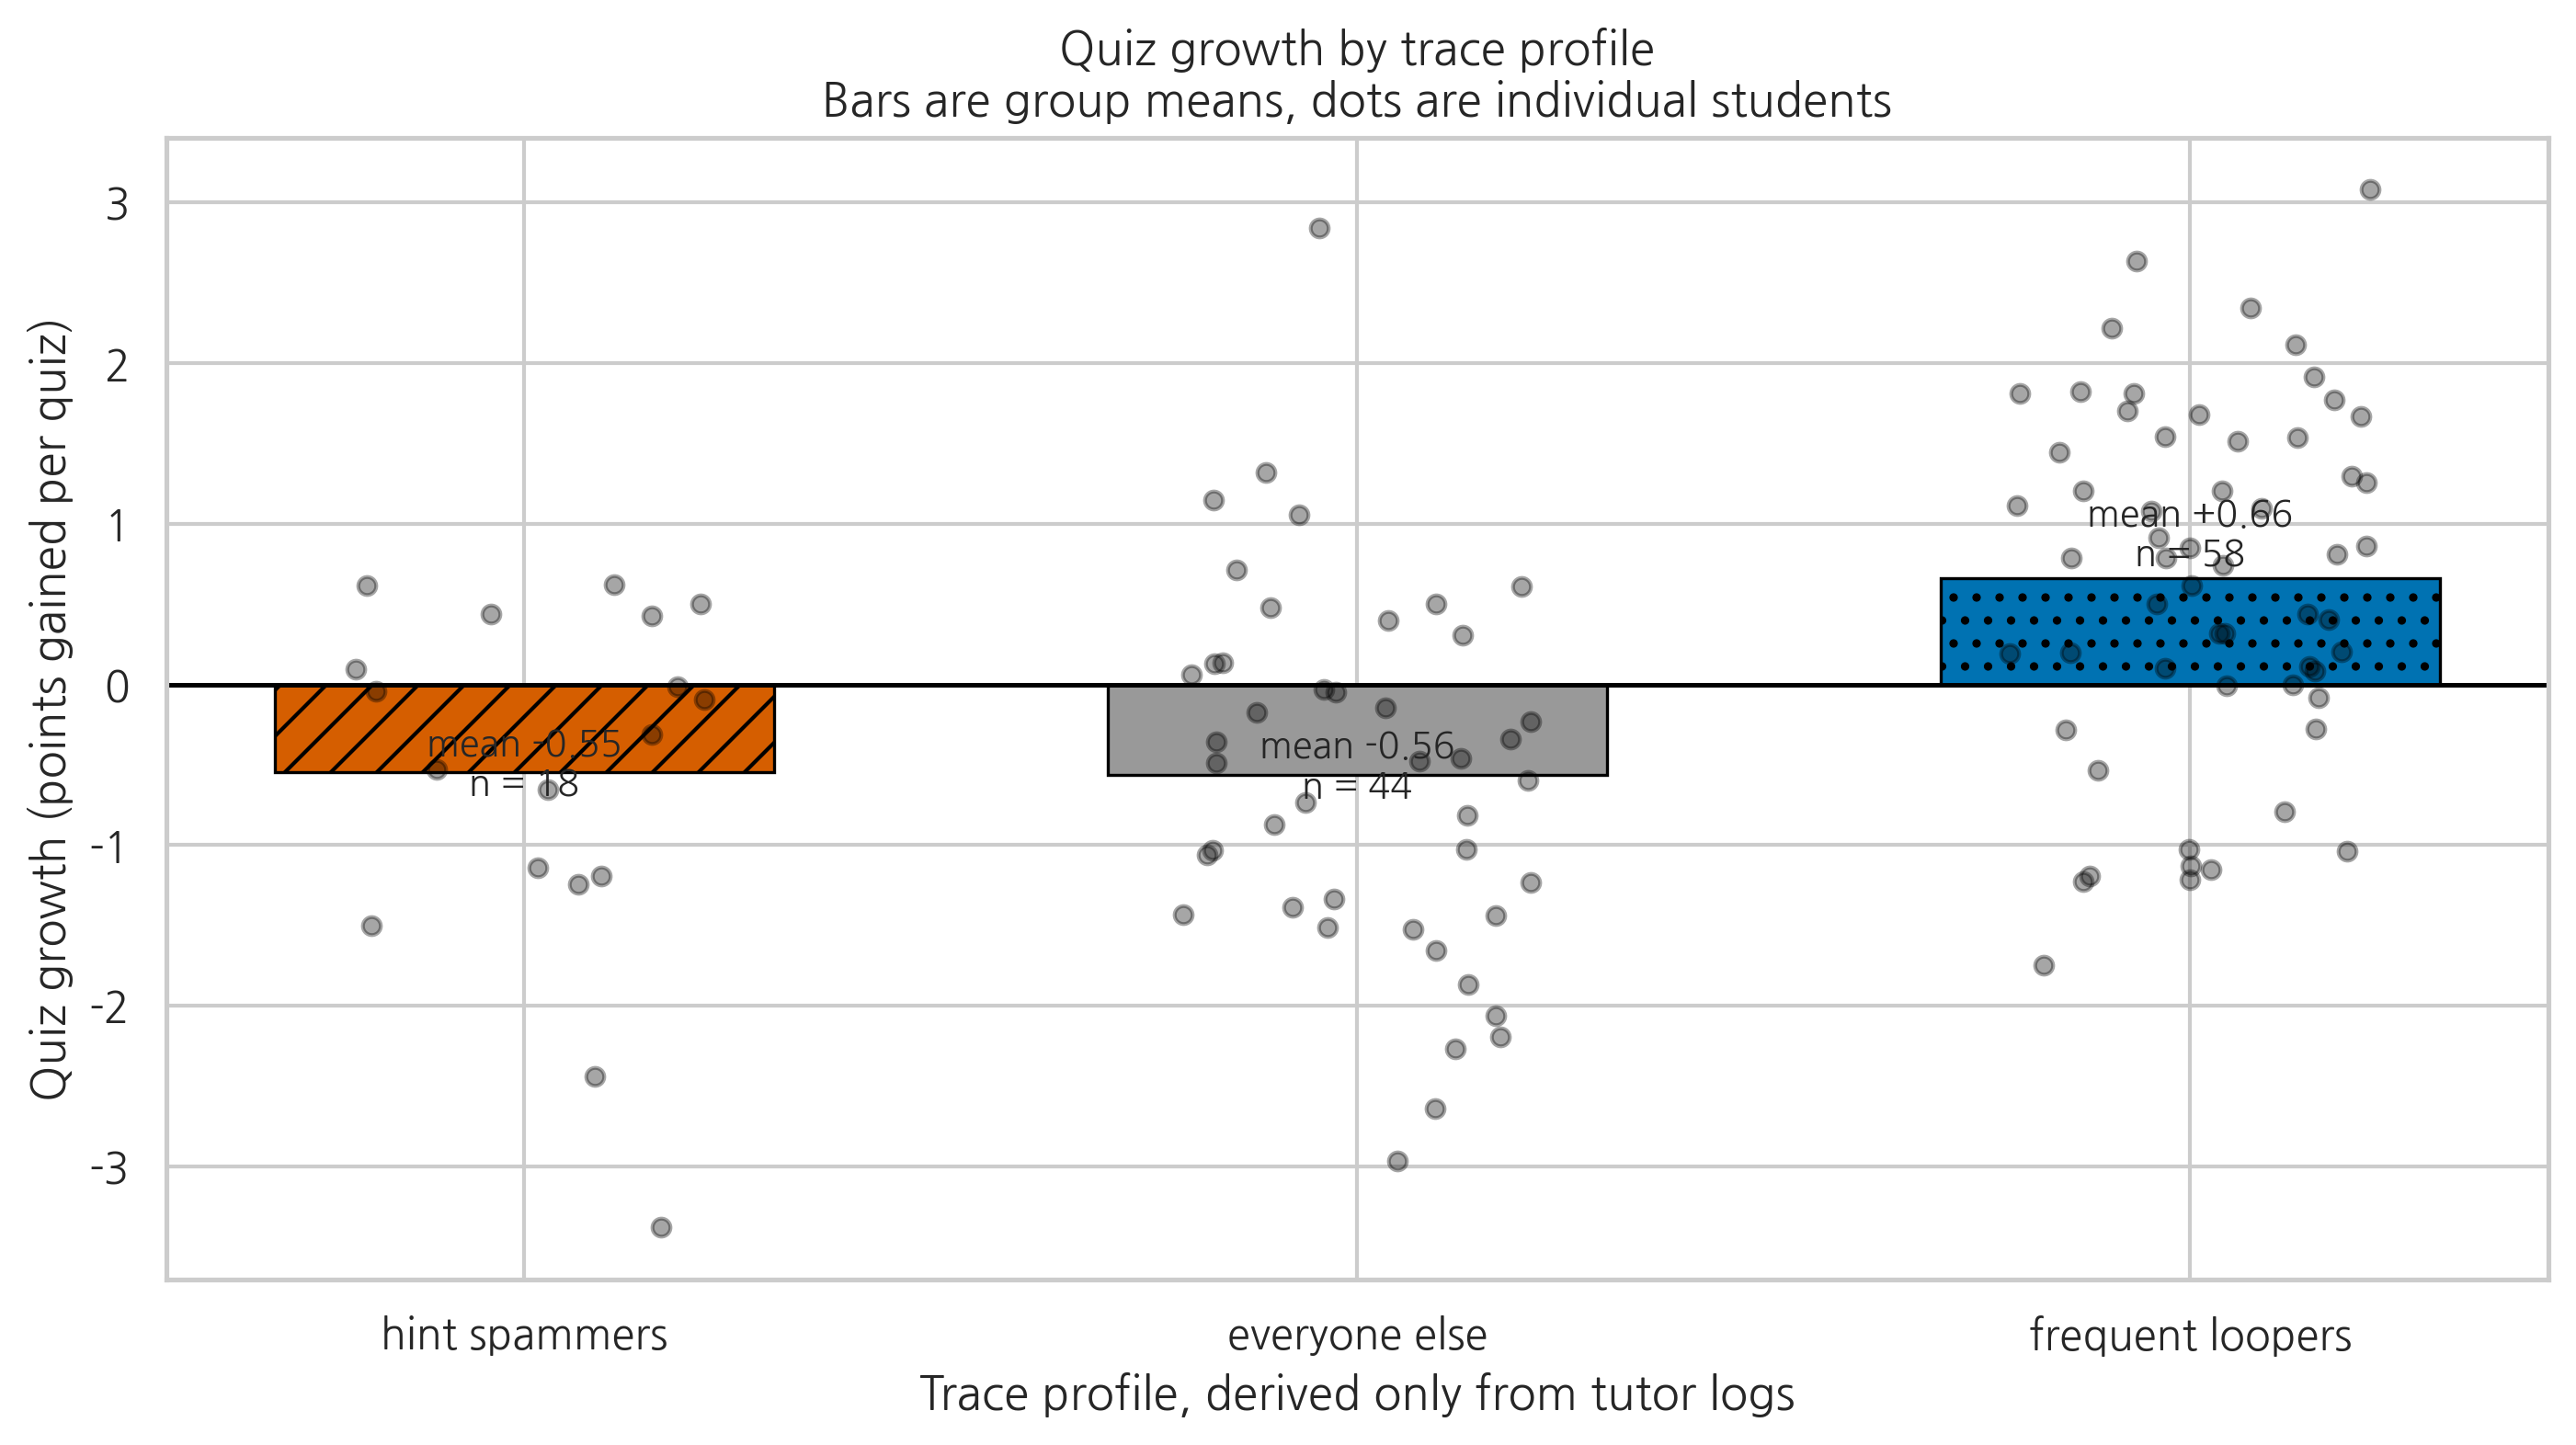

In [18]:
fig, ax = plt.subplots(figsize=(9.5, 5.4))
colours = {"hint spammers": "#D55E00", "everyone else": "#999999", "frequent loopers": "#0072B2"}
hatches = {"hint spammers": "//", "everyone else": "", "frequent loopers": ".."}
rng = np.random.default_rng(1010)

for i, name in enumerate(GROUP_ORDER):
    values = srl.loc[srl["profile"] == name, "quiz_slope"]
    ax.bar(i, values.mean(), width=0.6, color=colours[name], hatch=hatches[name],
           edgecolor="black", linewidth=0.8, zorder=2)
    ax.scatter(i + rng.uniform(-0.22, 0.22, len(values)), values,
               s=22, color="black", alpha=0.35, zorder=3)
    ax.text(i, values.mean() + (0.08 if values.mean() >= 0 else -0.14),
            f"mean {values.mean():+.2f}\nn = {len(values)}", ha="center", fontsize=9.5, zorder=4)

ax.axhline(0, color="black", linewidth=1.2)
ax.set_xticks(range(len(GROUP_ORDER)))
ax.set_xticklabels(GROUP_ORDER)
ax.set_ylabel("Quiz growth (points gained per quiz)")
ax.set_xlabel("Trace profile, derived only from tutor logs")
ax.set_title("Quiz growth by trace profile\nBars are group means, dots are individual students")
plt.tight_layout()
plt.show()

**Interpretation prompt, and this one has teeth.**

The frequent loopers sit clearly above zero and the other two groups sit below it. But look again: **hint spammers and "everyone else" have almost the same mean growth.** The gap that makes hint spamming look damaging is mostly a gap between hint spammers and *loopers*, not between hint spammers and ordinary students.

1. Rewrite the headline "hint spamming is associated with worse learning" so that it survives this chart. What did you have to give up?
2. The dots inside each bar overlap heavily. If you were the instructor of this course and someone handed you this chart with a list of the 18 flagged students, what would you be entitled to do on Monday morning? What would you refuse to do?
3. We never looked at `students.csv` today. Open it and ask who the 18 flagged students are: how many work long hours, how many are first generation, how many are multilingual? Week 3 taught us where bias enters a model. Where would it enter this one?

## 📊 5. What follows what: the transition heatmap

Loop rate compresses a whole session to one bit: yes or no. Transitions keep more of the sequence.

An **n-gram** is a run of n consecutive items. We use the simplest case, the **bigram**: every neighbouring pair of actions. Count all the pairs, arrange them in a grid with the earlier action as the row and the later action as the column, then divide each row by its total. Cell (row `attempt`, column `check_answer`) then reads: "when this student had just attempted, they checked their answer 72 percent of the time."

This is a first cousin of what Zhang, Borchers, and Barany do with ordered network analysis, and a much blunter instrument. Theirs models connections across a window of surrounding actions and weights them; ours only sees the action immediately next door. Keep that difference in mind when you read the picture.

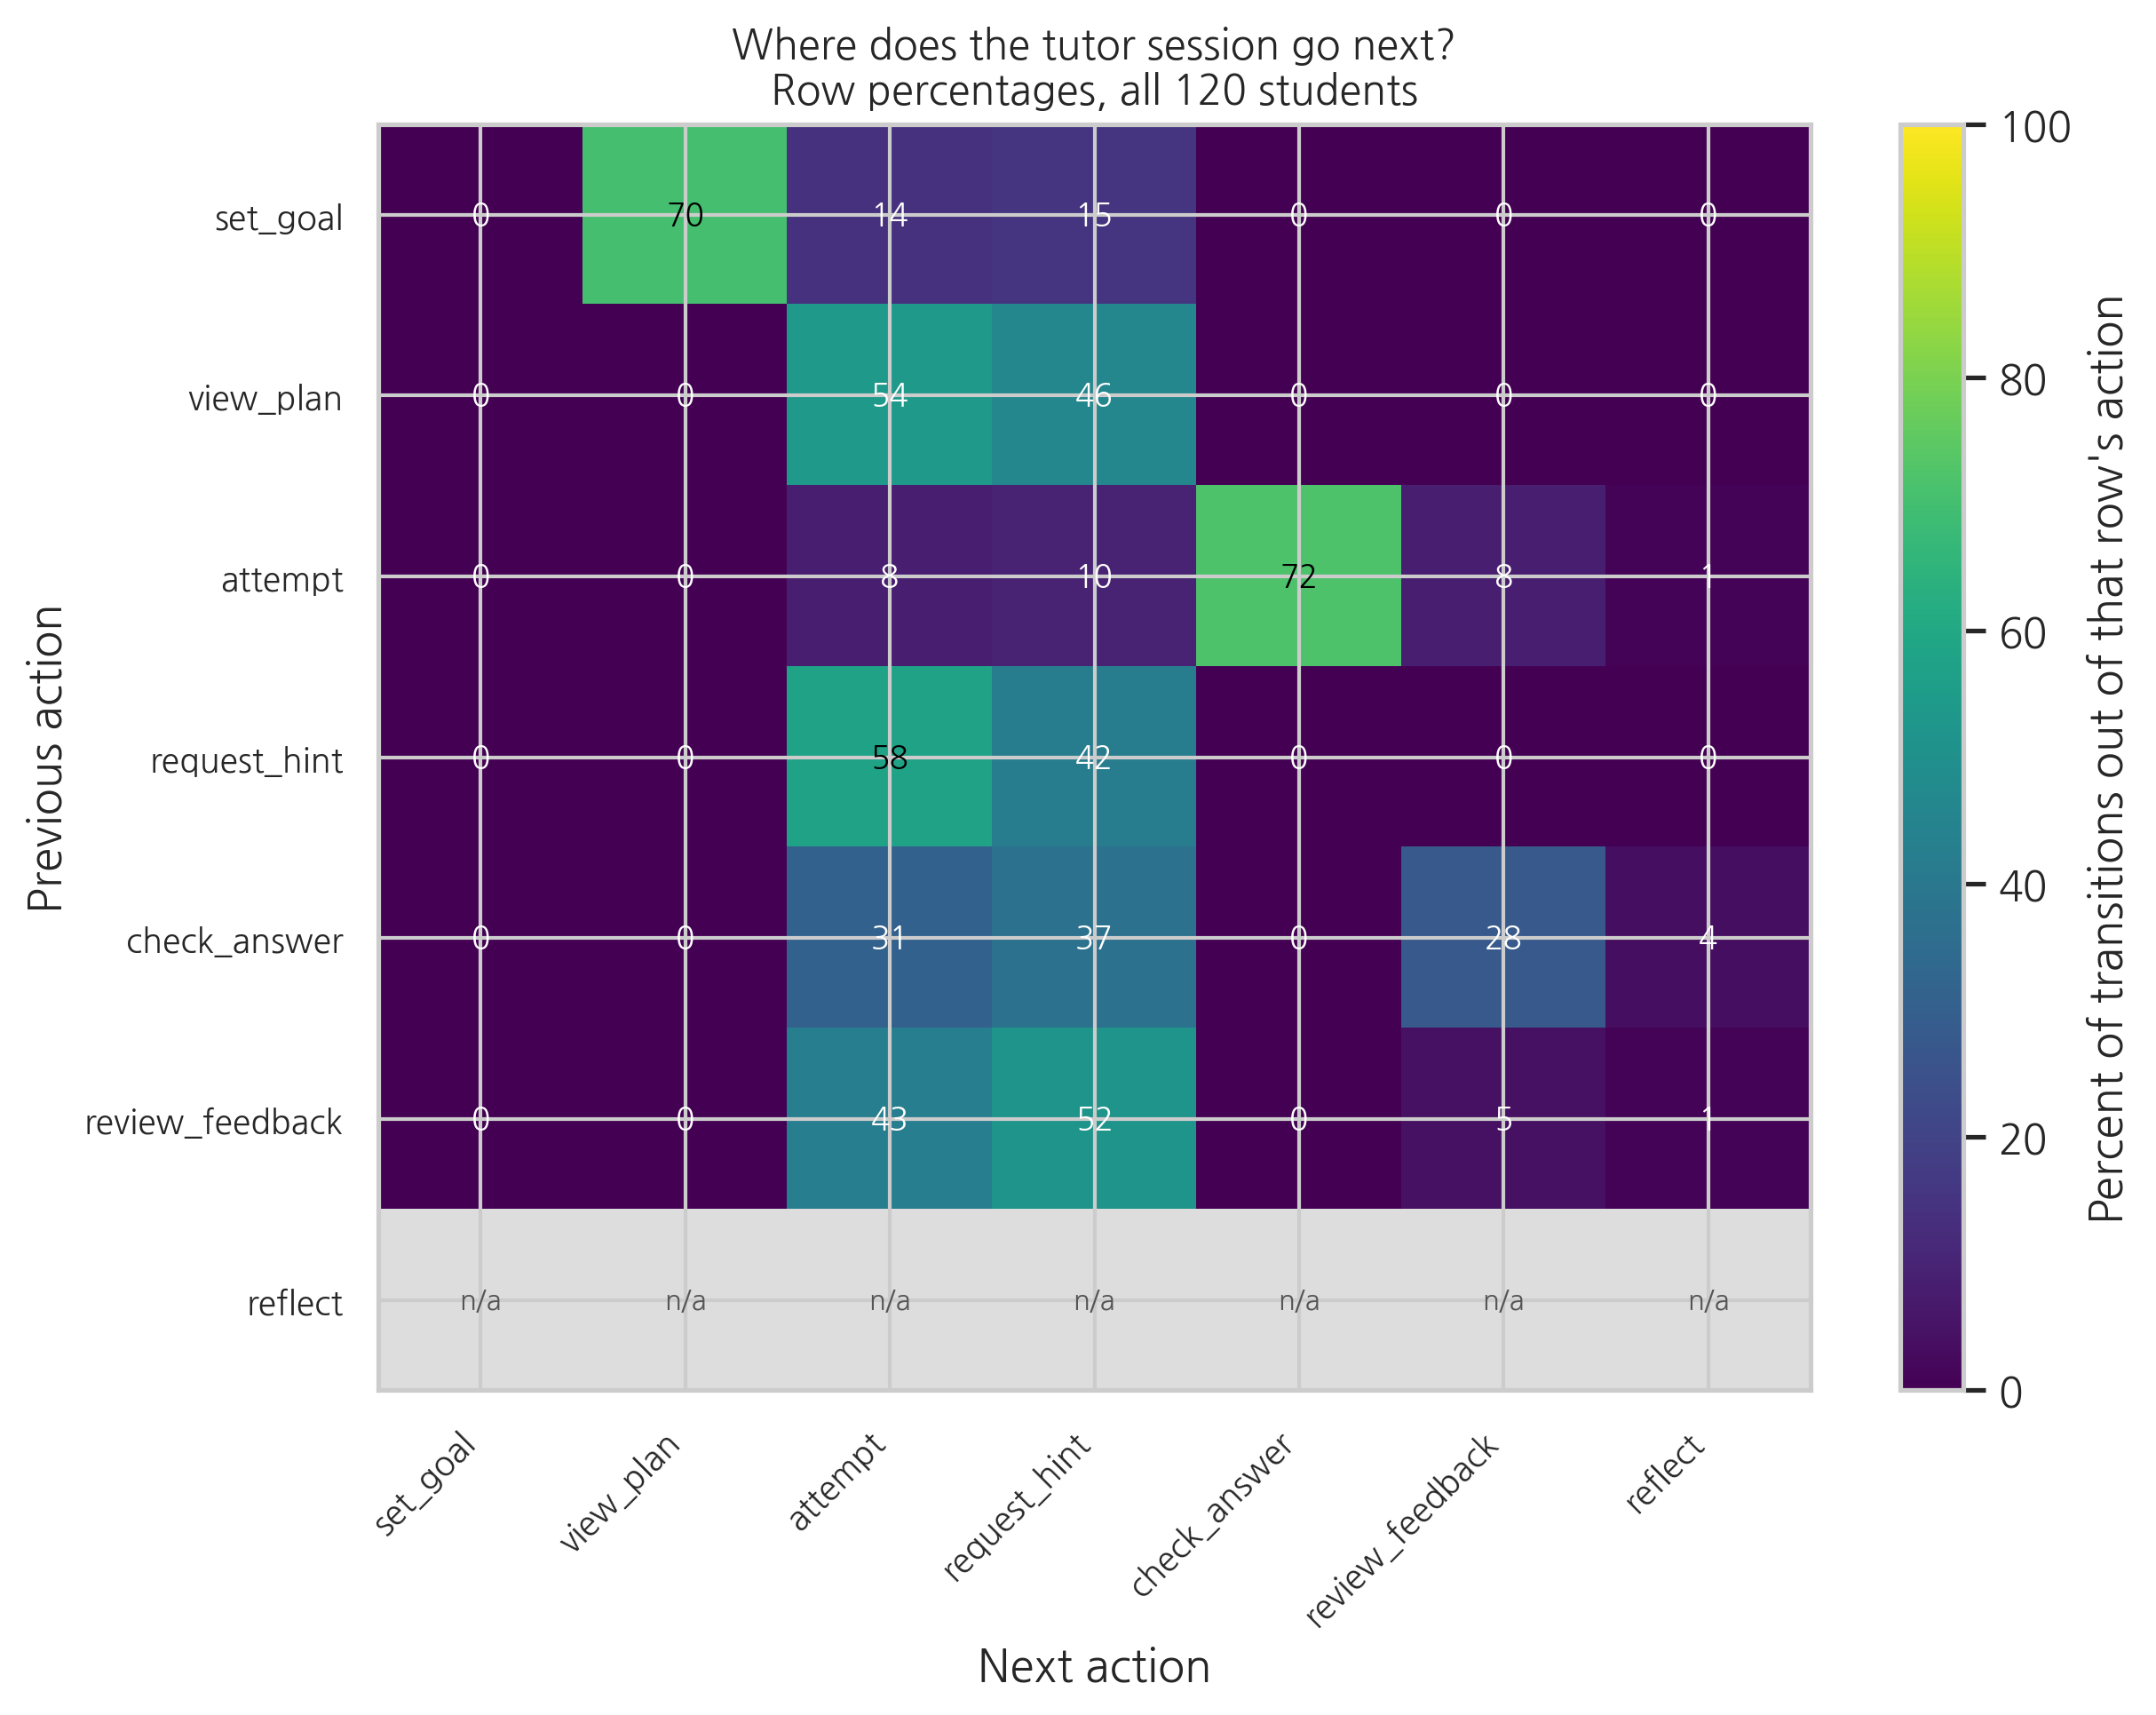

Rows sum to 100 percent. The reflect row is grey because reflect always ends a session,
so there is no 'next action' to record.


In [19]:
def transition_matrix(frame, actions=ACTIONS):
    """Row-normalized bigram matrix: P(next action | previous action)."""
    pairs = frame.dropna(subset=["previous_action"])
    counts = pd.crosstab(pairs["previous_action"], pairs["action"])
    counts = counts.reindex(index=actions, columns=actions, fill_value=0)
    row_totals = counts.sum(axis=1).replace(0, np.nan)
    return counts.div(row_totals, axis=0)

def draw_heatmap(ax, matrix, title, cmap="viridis", vmin=0, vmax=100, fmt="{:.0f}"):
    data = matrix.values * 100
    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad("#DDDDDD")
    image = ax.imshow(np.ma.masked_invalid(data), cmap=cmap_obj, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(ACTIONS)))
    ax.set_xticklabels(ACTIONS, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(len(ACTIONS)))
    ax.set_yticklabels(ACTIONS, fontsize=9)
    ax.set_xlabel("Next action")
    ax.set_ylabel("Previous action")
    ax.set_title(title, fontsize=11)
    span = vmax - vmin
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            value = data[i, j]
            if np.isnan(value):
                ax.text(j, i, "n/a", ha="center", va="center", fontsize=7.5, color="#555555")
            else:
                shade = "white" if (value - vmin) < span * 0.55 else "black"
                ax.text(j, i, fmt.format(value), ha="center", va="center",
                        fontsize=8.5, color=shade)
    return image

overall = transition_matrix(traces)

fig, ax = plt.subplots(figsize=(8.4, 6.6))
image = draw_heatmap(ax, overall,
                     "Where does the tutor session go next?\nRow percentages, all 120 students")
cbar = fig.colorbar(image, ax=ax)
cbar.set_label("Percent of transitions out of that row's action")
plt.tight_layout()
plt.show()

print("Rows sum to 100 percent. The reflect row is grey because reflect always ends a session,")
print("so there is no 'next action' to record.")

**Interpretation prompt.** Find the `request_hint` to `request_hint` cell. Across the whole class, a hint request is followed by another hint request 42 percent of the time. Now find `attempt` to `check_answer` at 72 percent.

1. Which single cell in this grid would you put on a teacher's dashboard, and what would the teacher do with it?
2. A class-level heatmap averages over 120 people. What kind of student could be completely invisible in this picture? Section 5.1 answers that; write your guess first.

### 5.1 The same grid, split by profile

Now compute the identical matrix twice: once using only the frequent loopers' actions, once using only the hint spammers'. The third panel subtracts one from the other, so orange means the loopers do it more and purple means the spammers do.

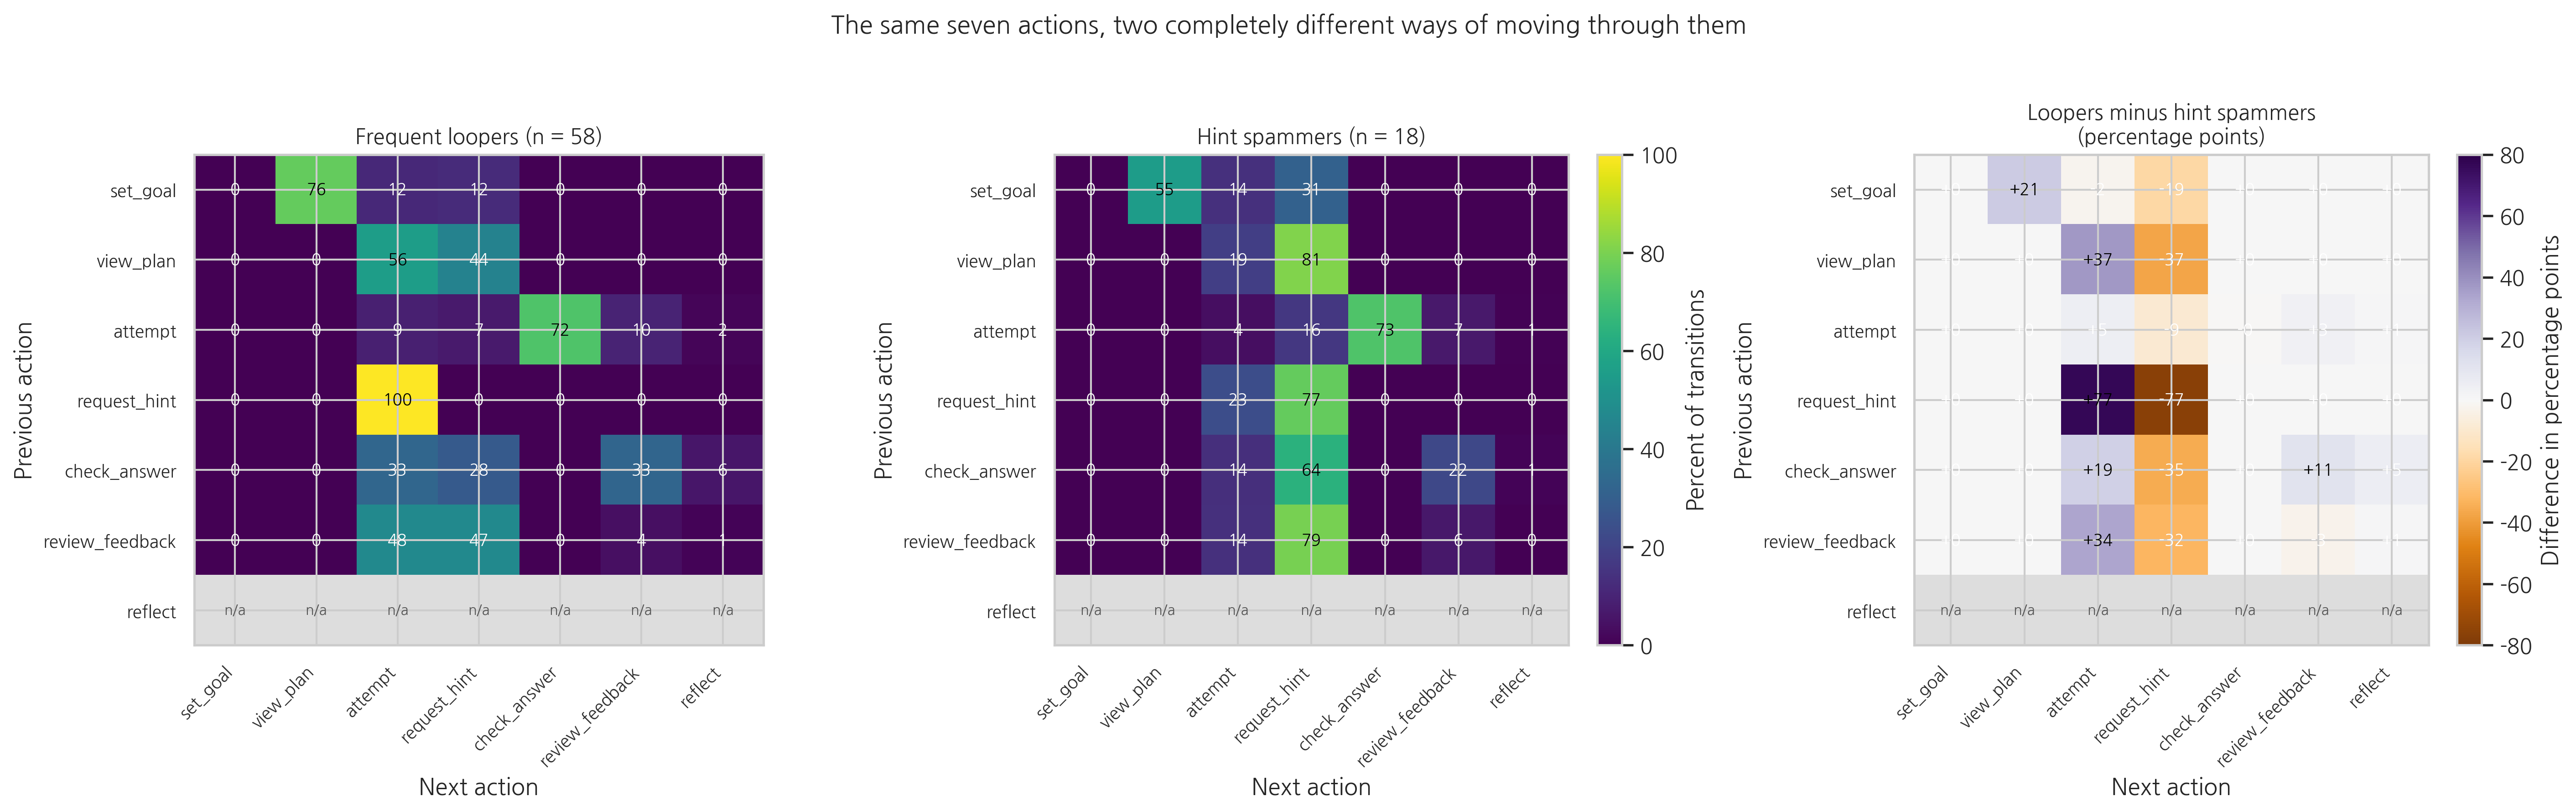

Selected cells, percent of transitions out of the row action
                                 frequent loopers  hint spammers
request_hint -> request_hint                  0.0           76.5
request_hint -> attempt                     100.0           23.5
check_answer -> review_feedback              32.6           21.7
check_answer -> reflect                       6.0            0.8
set_goal -> view_plan                        76.2           55.2


In [20]:
looper_ids = srl.index[srl["profile"] == "frequent loopers"]
spammer_ids = srl.index[srl["profile"] == "hint spammers"]

looper_matrix = transition_matrix(traces[traces["student_id"].isin(looper_ids)])
spammer_matrix = transition_matrix(traces[traces["student_id"].isin(spammer_ids)])
difference = looper_matrix - spammer_matrix

fig, axes = plt.subplots(1, 3, figsize=(19, 5.8))
img1 = draw_heatmap(axes[0], looper_matrix,
                    f"Frequent loopers (n = {len(looper_ids)})")
img2 = draw_heatmap(axes[1], spammer_matrix,
                    f"Hint spammers (n = {len(spammer_ids)})")
img3 = draw_heatmap(axes[2], difference, "Loopers minus hint spammers\n(percentage points)",
                    cmap="PuOr", vmin=-80, vmax=80, fmt="{:+.0f}")

fig.colorbar(img2, ax=axes[1], fraction=0.046).set_label("Percent of transitions")
fig.colorbar(img3, ax=axes[2], fraction=0.046).set_label("Difference in percentage points")
fig.suptitle("The same seven actions, two completely different ways of moving through them",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Selected cells, percent of transitions out of the row action")
compare = pd.DataFrame({
    "frequent loopers": [looper_matrix.loc["request_hint", "request_hint"] * 100,
                         looper_matrix.loc["request_hint", "attempt"] * 100,
                         looper_matrix.loc["check_answer", "review_feedback"] * 100,
                         looper_matrix.loc["check_answer", "reflect"] * 100,
                         looper_matrix.loc["set_goal", "view_plan"] * 100],
    "hint spammers": [spammer_matrix.loc["request_hint", "request_hint"] * 100,
                      spammer_matrix.loc["request_hint", "attempt"] * 100,
                      spammer_matrix.loc["check_answer", "review_feedback"] * 100,
                      spammer_matrix.loc["check_answer", "reflect"] * 100,
                      spammer_matrix.loc["set_goal", "view_plan"] * 100],
}, index=["request_hint -> request_hint", "request_hint -> attempt",
          "check_answer -> review_feedback", "check_answer -> reflect",
          "set_goal -> view_plan"]).round(1)
print(compare.to_string())

**Interpretation prompt.** The `request_hint` to `request_hint` cell is 0 percent for frequent loopers and 77 percent for hint spammers. That is about as stark as behavioral data gets, and it is worth pausing on why: our two groups were defined using hint timing in the first place, so of course they differ on hint transitions. That is circular, and naming the circularity is the point.

1. Which contrasts in the difference panel are **not** circular, that is, which ones involve no action we used to build the groups? Name two, and say what they suggest.
2. The heatmap treats a two second transition and a four minute transition as the same event. Design a fix. What would you have to add to the matrix, and what would you lose in readability?
3. Ordered network analysis, in the Zhang, Borchers, and Barany reading, connects actions across a window rather than only to their immediate neighbour. Looking at these three panels, what would a wider window let you see that you cannot see here?

### ✏️ Your turn 4 (stretch)

Instead of splitting by our derived profiles, split by an outcome and see whether the transitions still separate. The default splits students at the median quiz growth. Change `SPLIT_COLUMN` to `"loop_rate"` to split on regulation instead, or edit the grouping rule entirely.

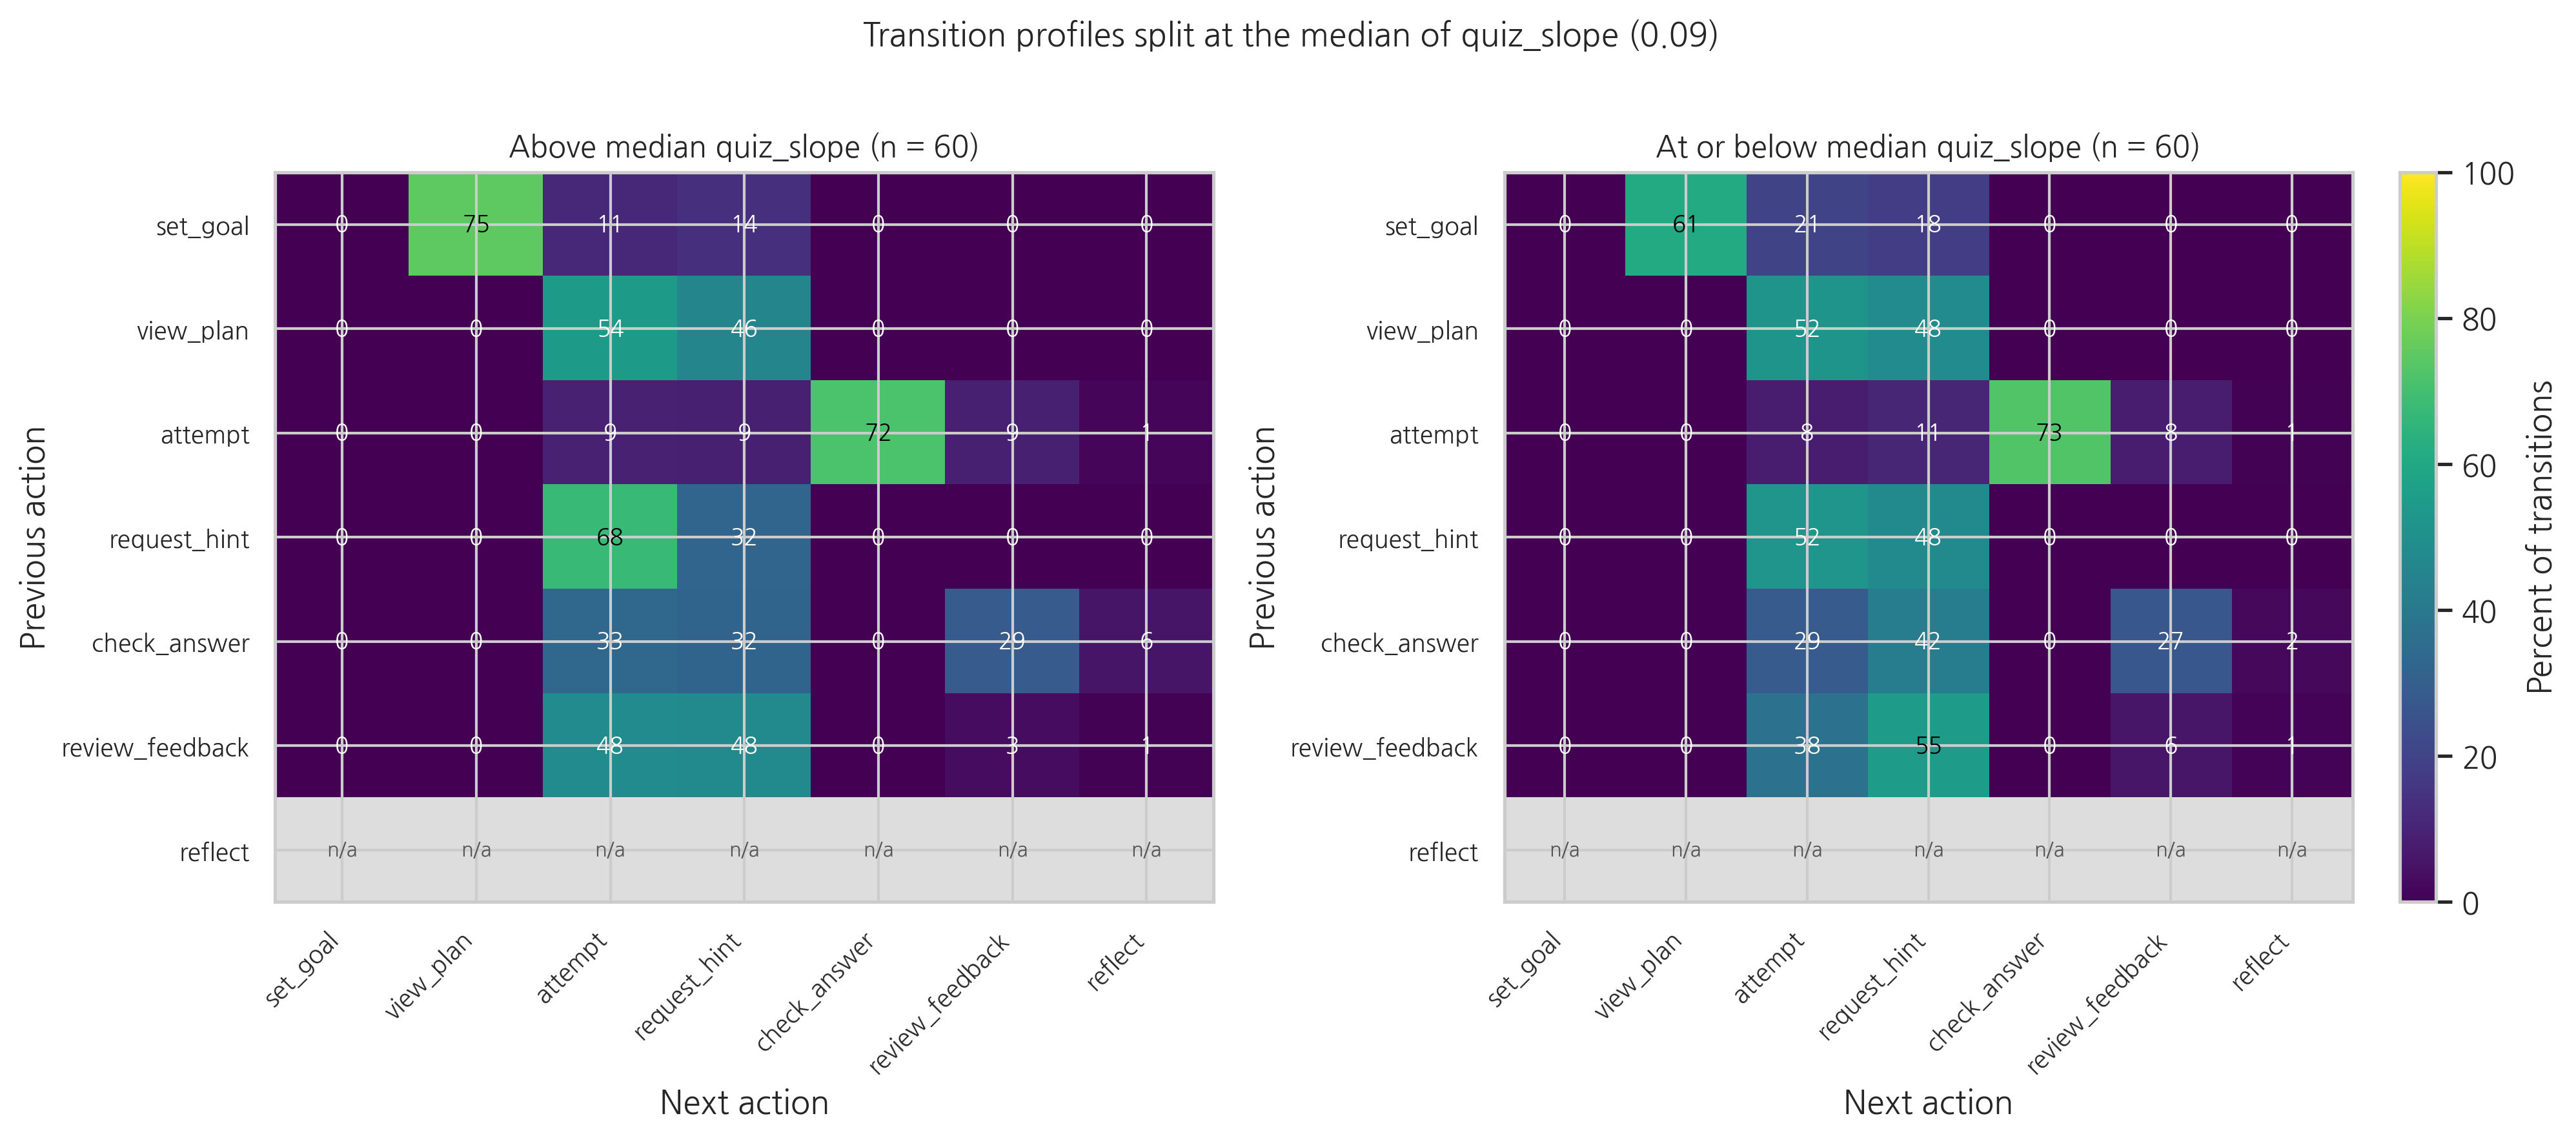

Largest differences between the two halves, in percentage points
      request_hint -> request_hint      -15.4
      request_hint -> attempt           +15.4
          set_goal -> view_plan         +14.0
   review_feedback -> attempt           +10.6
      check_answer -> request_hint       -9.9


In [21]:
# ✏️ TODO: try "loop_rate" instead of "quiz_slope".
SPLIT_COLUMN = "quiz_slope"

cutoff = srl[SPLIT_COLUMN].median()
high_ids = srl.index[srl[SPLIT_COLUMN] > cutoff]
low_ids = srl.index[srl[SPLIT_COLUMN] <= cutoff]

high_matrix = transition_matrix(traces[traces["student_id"].isin(high_ids)])
low_matrix = transition_matrix(traces[traces["student_id"].isin(low_ids)])

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.8))
draw_heatmap(axes[0], high_matrix, f"Above median {SPLIT_COLUMN} (n = {len(high_ids)})")
img = draw_heatmap(axes[1], low_matrix, f"At or below median {SPLIT_COLUMN} (n = {len(low_ids)})")
fig.colorbar(img, ax=axes[1], fraction=0.046).set_label("Percent of transitions")
fig.suptitle(f"Transition profiles split at the median of {SPLIT_COLUMN} "
             f"({cutoff:.2f})", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

biggest = (high_matrix - low_matrix).abs().stack().sort_values(ascending=False).head(5)
print("Largest differences between the two halves, in percentage points")
for (previous, nxt), value in ((high_matrix - low_matrix).stack()
                               .reindex(biggest.index).items()):
    print(f"  {previous:>16} -> {nxt:<16} {value * 100:+6.1f}")

## 💬 Reflection

Bring written answers to at least two of these. They are the spine of tonight's discussion.

**On Winne (2022), "Learning analytics for self-regulated learning."**
Winne argues that self-regulated learning is not directly observable and that traces are the footprints it leaves. Today you turned footprints into a loop rate. Name the single largest thing your loop rate measure gets wrong about a real student's regulation, and say whether more trace data would fix it or whether the problem is of a different kind.

**On Zhang, Borchers, and Barany (2024), "Studying the interplay of self-regulated learning cycles and scaffolding through ordered network analysis across three tutoring systems."**
Their analysis looks at how regulation cycles interact with the scaffolding the system offers, across three different tutors. Our tutor offers hints, feedback, and a plan view. Pick one of those three supports and argue, using something you saw in a chart today, that the support is shaping the regulation we measured rather than merely revealing it.

**On Viberg, Khalil, and Baars (2020), "Self-regulated learning and learning analytics in online learning environments."**
Their review asks how much learning analytics work on SRL actually measures SRL and how much of it measures activity wearing an SRL vocabulary. Where does today's notebook sit on that line? Be specific: which of our four measures would you defend as SRL, and which is activity with a nicer name?

**Across all three, and the course.**
In Week 3 we found that bias entered an at-risk model through a feature choice, not through the algorithm. Today we made at least six choices: which actions count as a goal, which count as closing a loop, ten seconds, three in a row, three bursts, and where to cut "frequent." Pick the one you think is most consequential and least defensible, and say what evidence would settle it.

### A question for our guest

Conrad Borchers joins us this week and is a coauthor of the Zhang, Borchers, and Barany reading. [Bio: confirm with speaker]

Come with a real question. The strongest ones come from something you actually just did. For example, our hint spam flag hangs on a ten second threshold that we picked, and ordered network analysis hangs on a window size that its analyst picks. A question worth asking:

> "When you build ordered networks across three different tutoring systems, how do you choose the window within which two actions count as connected, and how much do your substantive conclusions move when that choice changes? Is there a defensible way to report that sensitivity, or does the field just have to trust the analyst?"

Write your own version, or write a better one. Bring it on paper.

## ✅ Before you leave today

**There is nothing to upload to Canvas this week.** Week 7 has no mini project. This lab is a launch: we start it together in class and you finish reading and arguing with it on your own time. The next Canvas deliverable is Mini Project 4, due Week 8.

Checklist for tonight:

- [ ] The notebook ran top to bottom with no errors (**Runtime > Restart and run all**).
- [ ] You can state the definition of a **complete regulation loop** from memory. We use it again in Week 11.
- [ ] You changed at least one threshold in a **✏️ Your turn** cell and noticed what moved.
- [ ] You have written answers to at least two 💬 Reflection prompts.
- [ ] You have one question written down for Conrad Borchers.

**AI use, per the course policy.** AI assistance is permitted in designated activities and must be documented. There is no submission this week, so there is nothing to log today. The moment any of this code, or any AI conversation about it, makes its way into a mini project or your course research project, the full policy applies: you upload your AI interaction log and a short reflection alongside the work. Undisclosed use is an Honor Code violation. The habit that makes this painless is to keep the log as you go rather than reconstructing it afterward.

## Appendix: solutions to the ✏️ Your turn cells

These are worked versions, not the only right answers. Run them after you have tried your own.

### Solution 1: comparing several students' profiles at once

Rather than one student at a time, put a few side by side and let the differences do the talking.

Percent of each student's actions, by action type
student_id       S017  S047  S072  S003  class median
action                                               
set_goal          0.0   0.0   1.5   0.0           1.5
view_plan         0.0   0.0   1.5   0.0           0.9
attempt          33.7  16.6  19.9  45.9          37.5
request_hint     27.2  64.1  62.0  16.2          19.1
check_answer     24.4  11.8  12.9  32.4          27.1
review_feedback  14.7   7.3   1.8   5.4           9.0
reflect           0.0   0.1   0.4   0.0           1.3


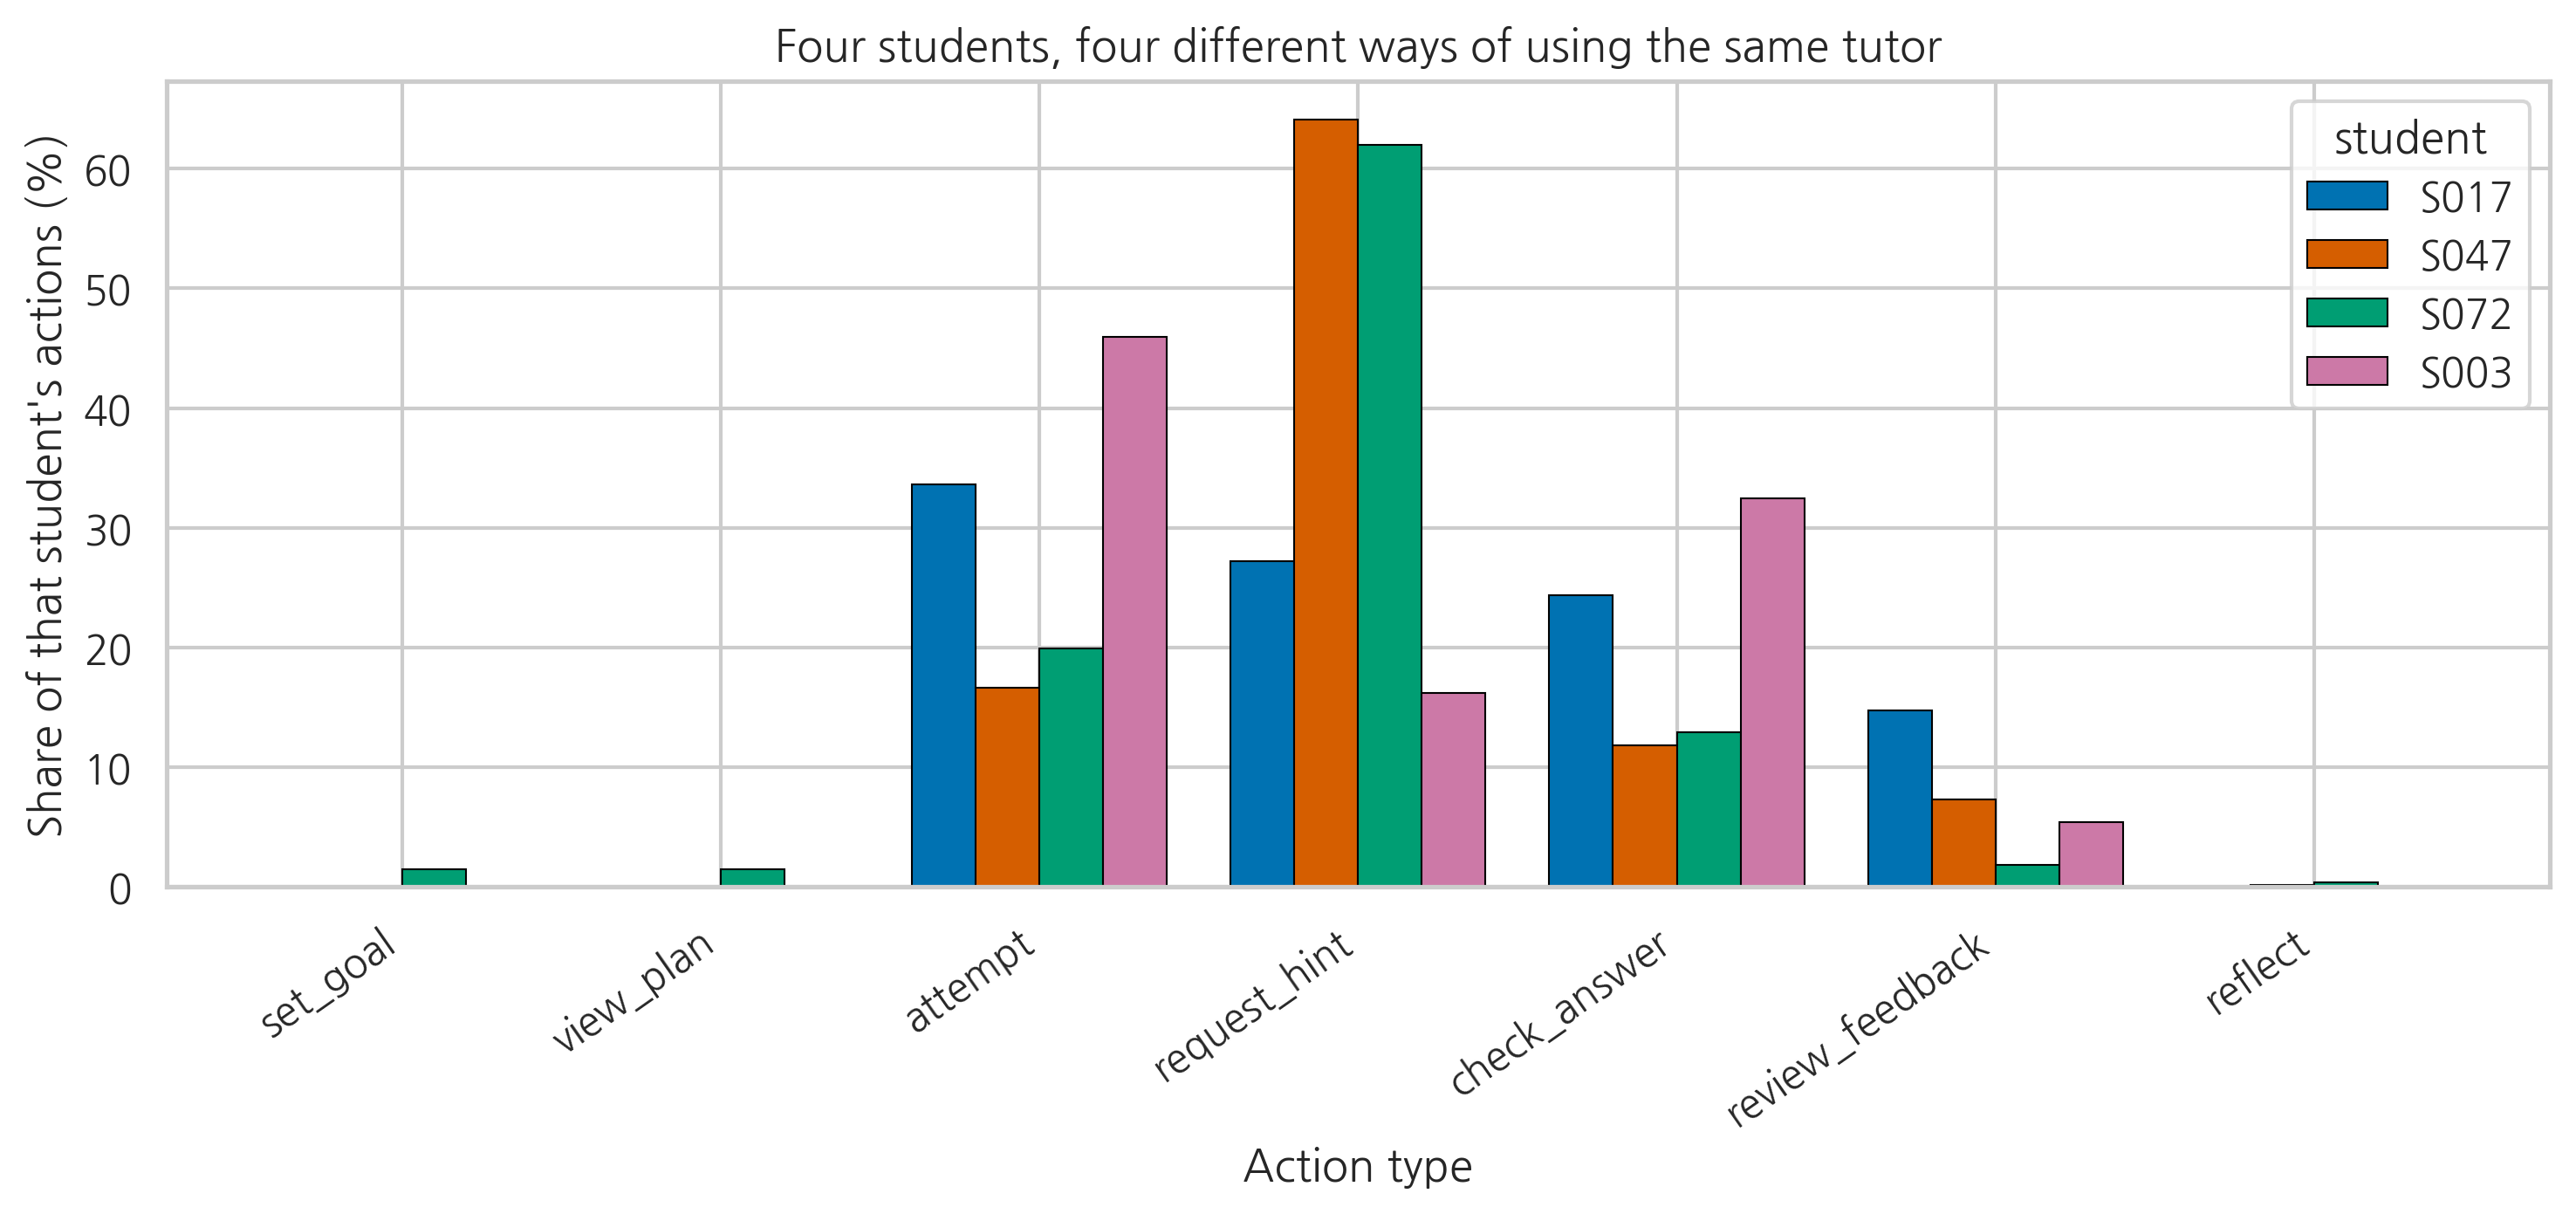

In [22]:
SOME_STUDENTS = ["S017", "S047", "S072", "S003"]

side_by_side = (profile.loc[SOME_STUDENTS] * 100).round(1).T
side_by_side["class median"] = (profile.median() * 100).round(1)
print("Percent of each student's actions, by action type")
print(side_by_side.to_string())

fig, ax = plt.subplots(figsize=(10, 4.8))
width = 0.2
positions = np.arange(len(ACTIONS))
palette = ["#0072B2", "#D55E00", "#009E73", "#CC79A7"]
for k, student_id in enumerate(SOME_STUDENTS):
    ax.bar(positions + (k - 1.5) * width, profile.loc[student_id, ACTIONS] * 100,
           width=width, label=student_id, color=palette[k], edgecolor="black", linewidth=0.5)
ax.set_xticks(positions)
ax.set_xticklabels(ACTIONS, rotation=35, ha="right")
ax.set_ylabel("Share of that student's actions (%)")
ax.set_xlabel("Action type")
ax.set_title("Four students, four different ways of using the same tutor")
ax.legend(title="student")
plt.tight_layout()
plt.show()

### Solution 2: how the loop definition changes the finding

Sweep several definitions of "closing the loop" and watch both the prevalence and the correlation move.

In [23]:
definitions = {
    "reflect only": ("reflect",),
    "review_feedback only": ("review_feedback",),
    "either one (notebook default)": ("review_feedback", "reflect"),
    "either one, or a plan view": ("review_feedback", "reflect", "view_plan"),
}

rows = []
for name, closers in definitions.items():
    flags = session_actions["action_sequence"].apply(
        lambda seq, c=closers: has_complete_loop(seq, closers=c))
    rate = flags.groupby(session_actions["student_id"]).mean()
    rows.append({"definition": name,
                 "sessions with a loop (%)": round(flags.mean() * 100, 1),
                 "correlation with quiz growth": round(rate.corr(quiz_slope), 2)})
print(pd.DataFrame(rows).to_string(index=False))
print()
print("The prevalence swings by tens of percentage points. The correlation moves much less,")
print("which is itself worth a sentence in a paper: the ordering of students is more stable")
print("than the headline number, so a claim about who regulates survives better than a claim")
print("about how much regulation happened.")

                   definition  sessions with a loop (%)  correlation with quiz growth
                 reflect only                      30.6                          0.52
         review_feedback only                      43.8                          0.53
either one (notebook default)                      48.6                          0.58
   either one, or a plan view                      48.6                          0.58

The prevalence swings by tens of percentage points. The correlation moves much less,
which is itself worth a sentence in a paper: the ordering of students is more stable
than the headline number, so a claim about who regulates survives better than a claim
about how much regulation happened.


### Solution 3: a sensitivity analysis of the hint spam threshold

One number at a time is fine for exploring. For an argument you want the whole surface.

In [24]:
gap_options = [3, 5, 10, 20, 45]
length_options = [2, 3, 4, 5]

grid = pd.DataFrame(index=[f"{g} s" for g in gap_options],
                    columns=[f"{n} in a row" for n in length_options], dtype=float)
for gap in gap_options:
    rapid = ((traces["action"] == "request_hint") &
             (traces["previous_action"] == "request_hint") &
             (traces["gap_s"] < gap))
    for length in length_options:
        bursts = rapid.groupby(traces["student_id"]).apply(
            lambda flags, L=length: count_bursts(flags, min_length=L))
        grid.loc[f"{gap} s", f"{length} in a row"] = int((bursts >= MIN_BURSTS_TO_FLAG).sum())

print("Students flagged as hint spamming, under every combination of thresholds")
print("(requiring at least", MIN_BURSTS_TO_FLAG, "bursts across the term)")
print(grid.astype(int).to_string())
print()
print("In this dataset the flag is remarkably stable, because the planted behavior is extreme:")
print("bursts of hints a few seconds apart, dozens of times. Do not generalize that stability.")
print("Report a table like this one whenever a threshold is doing load-bearing work in your argument.")

Students flagged as hint spamming, under every combination of thresholds
(requiring at least 3 bursts across the term)
      2 in a row  3 in a row  4 in a row  5 in a row
3 s           18          16           1           0
5 s           18          18          18          16
10 s          18          18          18          18
20 s          18          18          18          18
45 s          18          18          18          18

In this dataset the flag is remarkably stable, because the planted behavior is extreme:
bursts of hints a few seconds apart, dozens of times. Do not generalize that stability.
Report a table like this one whenever a threshold is doing load-bearing work in your argument.


### Solution 4: which transitions separate the outcome halves

A quick ranked list is often more useful than staring at a 7 by 7 grid.

In [25]:
above = srl.index[srl["quiz_slope"] > srl["quiz_slope"].median()]
below = srl.index[srl["quiz_slope"] <= srl["quiz_slope"].median()]
diff = (transition_matrix(traces[traces["student_id"].isin(above)]) -
        transition_matrix(traces[traces["student_id"].isin(below)])) * 100

ranked = diff.stack().dropna().sort_values(key=abs, ascending=False).head(8)
print("Transitions that most separate higher growth from lower growth students")
print("(positive means the higher growth half does it more, in percentage points)")
for (previous, nxt), value in ranked.items():
    print(f"  {previous:>16} -> {nxt:<18} {value:+6.1f}")
print()
print("Compare this list with the loopers versus spammers list. Any transition appearing in both")
print("is a candidate for a real behavioral signal. Any transition appearing only in the profile")
print("comparison is probably an artifact of how we drew the groups.")

Transitions that most separate higher growth from lower growth students
(positive means the higher growth half does it more, in percentage points)
      request_hint -> request_hint        -15.4
      request_hint -> attempt             +15.4
          set_goal -> view_plan           +14.0
   review_feedback -> attempt             +10.6
      check_answer -> request_hint         -9.9
          set_goal -> attempt              -9.7
   review_feedback -> request_hint         -7.4
      check_answer -> attempt              +4.7

Compare this list with the loopers versus spammers list. Any transition appearing in both
is a candidate for a real behavioral signal. Any transition appearing only in the profile
comparison is probably an artifact of how we drew the groups.


---

*EDIS 8100: Teaching and Learning Analytics. Course design and data universe by Dr. Hakeoung Hannah Lee, University of Virginia School of Education and Human Development. All data in this notebook are synthetic.*